# The five design strategies, head to head on EGFP → mOrange and EGFP → EBFP

Figures for the consolidated EGFP recolouring campaign ([`README.md`](README.md)): one scaffold
(**EGFP**, idx 171, `4EUL`, 488/507 nm), two targets that bracket the problem — **mOrange**
(548/562 nm, 30.4 % identity) and **EBFP** (380/440 nm, 99.2 % identity) — one 5 Å Tier-B edit
window, five ways of choosing residues inside it. The strategies share the engine
(`fpdesign.campaign`) and differ **only** in where candidate residues come from and whether anything
steers the choice among them, so a difference between two columns here is a difference between two
selection rules and nothing else.

Those two axes are what the figures are labelled by: every categorical axis below carries the
**steering** rule per column under a rule naming the **proposal** it belongs to, so the 2 × 2 (and
the one cell that was never run) is readable off the axis rather than out of a key.

| campaign # | figure label | campaign name | proposal | steering | pool read here |
|---|---|---|---|---|---|
| 1 | ESM-2 · Gibbs | `gibbs` | ESM-2 masked LM | none (target-free) | [`gibbs-sampling/designs_benchmark375/`](gibbs-sampling/designs_benchmark375/) |
| 2 | ESM-2 · Spectrum | `spectra guide` | ESM-2 masked LM | surrogate peaks only | [`esm2_guided/designs/`](esm2_guided/designs/), λ_bright = 0, λ_edit = 0 |
| 4 | ESM-2 · Spectrum + brightness | `DMS guide` | ESM-2 masked LM | peaks + brightness + edit penalty | [`esm2_guided/designs/`](esm2_guided/designs/), λ_bright > 0 |
| 6 | MSA · Gibbs | `MSA gibbs` | 763-sequence family profile | none (target-free) | [`msa-gibbs/designs_benchmark375/`](msa-gibbs/designs_benchmark375/) |
| 5 | MSA · Spectrum + brightness | `MSA guide` | the same family profile | peaks + brightness + edit penalty | [`msa-guided/designs/`](msa-guided/designs/), **first 3 trials of every cell** |

The campaign's numbering has a gap because its **strategy 3**, the constrained spectra guide
(λ_bright = 0, λ_edit > 0), was retired: its 20 cells are still on disk and are excluded here exactly
as they are in [`benchmark_report.py`](benchmark_report.py) and
[`esm2_guided/analyze.py`](esm2_guided/analyze.py), so the ESM-2 sweep contributes 105 of its 125
cells. There is no MSA · Spectrum run — the family profile was only ever tried with the full
objective — so that cell of the 2 × 2 is simply absent from every axis.

**Colour names a protein, never a strategy: orange for mOrange, blue for EBFP, green for EGFP.** It
appears where those proteins do — on the two **reference rules** of Figures 2 and 3, each named once
on the excitation panel, and on the markers of Figures 4 and 5, where the two campaigns share an
axis and colour is the only thing that separates them. Everywhere else a design is neutral grey:
what a reader judges in Figures 2 and 3 is where a cloud of designs sits between two rules, and
colouring the designs as well would say the target twice. A **target-free** pool keeps the warm grey
in every figure, because one run served both campaigns and it has no target to name. The five strategies are told apart by their position
on the axis, so the same column in two figures is the same strategy; the two **gibbs** strategies
never see a target at all — one target-free run serves both — which is why Figure 1 pools the two
targets into one pair of bars per strategy rather than splitting them.

**Equal budget, deliberately.** Every pool is ≈ 1,125 raw designs (cells × trials × 3 iteration
rounds), so no strategy wins by having drawn more. The MSA guide was run at 12 trials per cell —
four times everyone else — so it is **subsampled to its first 3 trials** here. Its per-trial seeding
(`SEED + si*131 + trial*17`) makes that subsample exact rather than approximate. The two
target-free strategies are read from their `designs_benchmark375/` runs (375 trials × 3 rounds),
**not** from the 96-trial `designs/` runs that back the wet-lab shortlists.

**Everything on these axes is the surrogate's own opinion.** The model that *guided* the search is
the model that *predicts* each design's `(ex, em)`, and it was trained on all FP data — these
popular FPs included. `pred_ex`/`pred_em`/`pred_bright` are in-sample and optimistic: they are the
design objective, not validation. The real judge is experiment, and the shortlists in
[`shortlists/`](shortlists/) are what went to it.

**The two deployability filters, and the one rule dropped.** A design is only worth a wet-lab slot
if the surrogate's opinion of it can be trusted at all, which is what the shortlists' two filters
test: **in-distribution** (ESM-2 max-pool NN distance to the 40,000-sequence GFP-DMS reference
≤ its 99th percentile, p99 ≈ 30.2 — an extrapolation check on the surrogate, not a property of the
protein) and **confidently bright** (classifier logit > 0.5). Figure 1 measures both on every pool;
Figures 2 and 3 *apply* them, to the two strategies that were guided on brightness, when
each one's best ten is picked. Both come from
[`make_shortlist_case.py`](make_shortlist_case.py) so the bar is identical to the one the shortlists
select on. What this notebook drops is the shortlists' **diversity** rule (a greedy top ten
≥ 5 residues apart); the printouts show what that costs.

| figure | what it shows |
|---|---|
| 1 | the share of every pool that survives each filter, both targets |
| 2 | every mOrange design's predicted peaks, with the ten each strategy would put forward |
| 3 | the same figure for EBFP |
| 4 | the MAE of every strategy's best ten, one target per panel |
| 5 | the two peaks of the same ten, both campaigns on one axis |

Figures are written to `figures_benchmark/`. [`figures/`](figures/) is **frozen** — those 13 PNGs
came from the retired `visualize_campaign.ipynb` and are not regenerable — so nothing here touches
it.

In [1]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000px panel really is 1000px.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

import os
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import arcadia_pycolor as apc

# Fonts are produced under dataset_pipeline/ and are shared and split-independent -- read from
# there unchanged, exactly as the other notebooks in this repo do.
FONTS = "../dataset_pipeline/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: run `python fetch_arcadia_fonts.py` in dataset_pipeline/ for the Atkinson faces")

# apc sets figure.dpi to 72 so that one point equals one style-guide pixel. Keep that
# correspondence for layout, but render at 2x so the inline PNGs are not soft on screen.
plt.rcParams["figure.dpi"] = 144
RNG_SEED = 0

CAMP = Path(".").resolve()
sys.path.insert(0, str(CAMP))

# figures/ is FROZEN (see the header): this notebook writes its own directory.
FIGDIR = "figures_benchmark"
os.makedirs(FIGDIR, exist_ok=True)

TARGETS = ["mOrange", "EBFP"]   # the campaign's two, in the order the figures take them
MSA_TRIALS = 3                  # the MSA guide's equal-budget subsample

### Style-guide helpers

The subset of the repo's plotting helpers these figures use, unchanged, so a panel here and a panel
in [`../in-silico-test/visualization_task2.ipynb`](../in-silico-test/visualization_task2.ipynb) are
drawn to the same rules.

In [2]:
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

PX = 1 / 72                       # one style-guide pixel, expressed in inches
FULL_WIDE, FLOAT, HALF_SQUARE = 1000, 650, 490

# Text roles, straight from the guide's "Text styles" page
ANNOTATION = dict(fontsize=15, fontweight="ultralight", color=str(apc.charcoal))
NUMBER_NOTE = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5,
                   color=str(apc.charcoal))
# The same role one size down, for notes that sit inside a crowded panel rather than beside it.
ANNOT = dict(fontsize=11, fontweight="ultralight", color=str(apc.charcoal))
# The two levels of every categorical x axis -- steering per column, proposal per group. Every
# figure in the notebook labels its x axis through `family_axis`, so these two are the only knob.
STEER_SIZE, FAMILY_SIZE = 14.5, 18

NEUTRAL, NEUTRAL_SOFT, DARK = str(apc.chateau), str(apc.taupe), str(apc.slate)


def tint(color, f):
    """A fill: the series' own colour lightened towards the page, so markers stay on top of it."""
    return tuple(1 - f + f * c for c in to_rgb(color))


def strip_spines(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def mean_sd_bar(ax, x, m, sd, half=0.28, cap=None, color=None, zorder=5):
    """The glyph a set of ten designs is summarised with: a mean crossbar and a capped ± 1 SD
    whisker. Defined once so Figure 4's crossbar is the same object as Figures 2 and 3's, and the
    caps say where the whisker ends rather than leaving it to fade into the markers behind it.
    """
    color = color or str(apc.charcoal)
    cap = 0.25 * half if cap is None else cap
    ax.plot([x - half, x + half], [m] * 2, color=color, lw=1.8, zorder=zorder,
            solid_capstyle="butt")
    if sd is None or not np.isfinite(sd):             # a single design has no spread to draw
        return
    ax.plot([x, x], [m - sd, m + sd], color=color, lw=1.1, zorder=zorder)
    for y in (m - sd, m + sd):
        ax.plot([x - cap, x + cap], [y] * 2, color=color, lw=1.1, zorder=zorder,
                solid_capstyle="butt")


# ---- colour: the two proteins the problem is defined by -----------------------------------------
# Colour names a protein and nothing else -- the target and the EGFP scaffold, on the two reference
# rules of Figures 2 and 3. Strategy is carried by position on the axis, and everything a strategy
# produced is drawn in a neutral: what a reader judges is where a cloud of designs sits relative to
# those two rules, and colouring the designs as well would say the target twice.
TARGET_COLOR = {"mOrange": str(apc.amber), "EBFP": str(apc.aegean)}
SCAFFOLD_COLOR = str(apc.lime)                          # EGFP, the scaffold every design starts from
BAR_COLOR = str(apc.bark)                               # Figure 1's bars, light tint and full
POOL_COLOR, TOP_COLOR = str(apc.taupe), str(apc.bark)   # the pool, and the ten drawn over it
TRUE_PEAKS = {"mOrange": (548, 562), "EBFP": (380, 440)}     # the measured target peaks

# ---- the strategies, ordered proposal-then-steering ---------------------------------------------
ORDER = ["ESM-2 gibbs", "Spectra guide", "Spectra + brightness guide", "MSA gibbs", "MSA guide"]
# The two levels every categorical axis is labelled with: the proposal groups the columns, the
# steering names each one. Internal keys and printouts keep the campaign's own names (the README,
# the shortlists and benchmark_report.py all use them); these are the display forms.
FAMILY = {"ESM-2 gibbs": "ESM-2", "Spectra guide": "ESM-2", "Spectra + brightness guide": "ESM-2",
          "MSA gibbs": "MSA", "MSA guide": "MSA"}
FAMILY_ORDER = ["ESM-2", "MSA"]
STEER = {"ESM-2 gibbs": "Gibbs", "Spectra guide": "Spectrum",
         "Spectra + brightness guide": "Spectrum +\nbrightness",
         "MSA gibbs": "Gibbs", "MSA guide": "Spectrum +\nbrightness"}
# The strategies whose objective contains the brightness term. Only these are filtered when a top
# ten is picked -- holding a strategy to a criterion it was never given would report the filter.
GATED = {"Spectra + brightness guide", "MSA guide"}
# Target-free: one run per scaffold serves both targets, so these two have no per-target pool.
TARGET_FREE = {"ESM-2 gibbs", "MSA gibbs"}
XPOS = {s: i for i, s in enumerate(ORDER)}


def family_axis(ax, extra=None, rule=-0.15, text=-0.185):
    """Label the categorical x axis on two levels: steering per column, proposal per group.

    `extra` adds a per-strategy suffix (used for an "n = " line when a filter shortens a column).
    The group rule and its name are drawn in axes-fraction coordinates on the y axis, so they sit
    outside the data area without needing an artist inside it.
    """
    lab = {k: v + (extra or {}).get(k, "") for k, v in STEER.items()}
    ax.set_xticks(range(len(ORDER)), [lab[k] for k in ORDER], fontsize=STEER_SIZE)
    tr = ax.get_xaxis_transform()
    for fam in FAMILY_ORDER:
        i = [XPOS[k] for k in ORDER if FAMILY[k] == fam]
        x0, x1 = min(i) - 0.42, max(i) + 0.42
        ax.plot([x0, x1], [rule] * 2, transform=tr, color=NEUTRAL, lw=1, clip_on=False,
                solid_capstyle="butt")
        ax.text(0.5 * (x0 + x1), text, fam, transform=tr, ha="center", va="top",
                fontsize=FAMILY_SIZE, color=str(apc.charcoal))

## 1. The five pools, on both targets

Every strategy's designs come off disk exactly as
[`benchmark_report.py`](benchmark_report.py) pools them — all trials, **iteration rounds ≥ 1**
(round 0 is the untouched scaffold), one row per design. Three things are then reconstructed:

- **`peak_err` for the target-free strategies.** The two gibbs CSVs never saw a target, so they
  carry no `peak_err`; it is recomputed per target as `½(|Δex| + |Δem|)`, which is what
  `make_shortlist_case.build` does for those cases. Their pool is *the same 1,125 sequences under
  both targets* — only the error changes — which is the correct parity with a guided strategy's
  1,125 per target, not half of it.
- **`pred_bright` for the target-free strategies.** Their runs never loaded the classifier, so those
  2,250 sequences are scored here with the same `brightness_cnn-max-d2_40k` net every other
  strategy was judged by, imported from `make_shortlist_case` rather than re-instantiated (≈ 70 s).
- **The in-distribution test**, for everything: the NN distance from a design's max-pooled ESM-2
  embedding to the 40,000-sequence GFP-DMS reference, against that reference's own 99th percentile.
  Embeddings are cached by sequence in `.embed_cache/`, so this is seconds when warm and minutes of
  GPU when cold.

**The unit is the design a run handed back**, duplicates included — a strategy that keeps
re-proposing the same sequence really did spend its budget that way, and `raw` is what the equal
budget is equal in. Deduplicated counts are printed beside every rate that could be moved by them,
and the top-ten selection dedupes (a top ten of one sequence repeated is not a top ten).

In [3]:
CELL = re.compile(r"lam-ex([\d.]+)_lam-em([\d.]+)_lam-bright([\d.]+)_lam-edit([\d.]+)$")


def esm2_slice(target, keep):
    """The cells of the matched-lambda ESM-2 sweep whose (lam_bright, lam_edit) pass `keep`."""
    out = []
    for p in sorted((CAMP / "esm2_guided" / "designs").glob(f"*/design_EGFP-{target}.csv")):
        _, _, b, e = (float(x) for x in CELL.match(p.parent.name).groups())
        if keep(b, e):
            out.append(p)
    return out


def pools(target):
    """(label, paths, target_free, trial cap) per strategy, in figure order.

    Strategy 3 of the campaign -- the retired constrained spectra guide, lam_bright = 0 and
    lam_edit > 0 -- matches neither ESM-2 slice and so is excluded, which is why the two guided
    ESM-2 rows account for 105 of the sweep's 125 cells.
    """
    return [
        ("ESM-2 gibbs",
         [CAMP / "gibbs-sampling" / "designs_benchmark375" / "design_EGFP.csv"], True, None),
        ("Spectra guide", esm2_slice(target, lambda b, e: b == 0 and e == 0), False, None),
        ("Spectra + brightness guide", esm2_slice(target, lambda b, e: b > 0), False, None),
        ("MSA gibbs",
         [CAMP / "msa-gibbs" / "designs_benchmark375" / "design_EGFP.csv"], True, None),
        ("MSA guide",
         sorted((CAMP / "msa-guided" / "designs").glob(f"*/design_EGFP-{target}.csv")),
         False, MSA_TRIALS),
    ]


KEEP = ["strategy", "target", "_cell", "trial", "round", "pred_ex", "pred_em", "peak_err",
        "pred_bright", "designed_seq", "_base"]
REF, frames, budget = {}, [], []
for target in TARGETS:
    ref = pd.read_csv(CAMP / "references" / f"reference_EGFP-{target}.csv").iloc[0]
    REF[target] = ref
    tex, tem = float(ref["target_ex"]), float(ref["target_em"])
    assert [p[0] for p in pools(target)] == ORDER
    for label, paths, tfree, tcap in pools(target):
        d = pd.concat([pd.read_csv(p).assign(_cell=p.parent.name) for p in paths],
                      ignore_index=True)
        if tcap is not None:
            d = d[d["trial"] < tcap]
        # The scaffold as the SURROGATE reads it: round 0 is the untouched EGFP sequence, so this
        # is one number per pool (489.2 / 507.3 nm) up to fp16 noise between runs.
        r0 = d[d["round"] == 0]
        base = float(0.5 * ((r0["pred_ex"] - tex).abs() + (r0["pred_em"] - tem).abs()).mean())
        d = d[d["round"] >= 1].copy()
        if tfree:
            d["peak_err"] = 0.5 * ((d["pred_ex"] - tex).abs() + (d["pred_em"] - tem).abs())
            d["pred_bright"] = np.nan
        d["strategy"], d["target"], d["_base"] = label, target, base
        frames.append(d[KEEP])
        budget.append(dict(strategy=label, target=target, target_free=tfree,
                           cells=d["_cell"].nunique(),
                           trials_cell=d.groupby("_cell")["trial"].nunique().unique().tolist(),
                           raw=len(d), unique=d["designed_seq"].nunique(),
                           scaffold_ex=round(r0["pred_ex"].mean(), 1),
                           scaffold_em=round(r0["pred_em"].mean(), 1), base_err=round(base, 2)))
D = pd.concat(frames, ignore_index=True)
SCAF = REF[TARGETS[0]]["scaffold_seq"]
print(pd.DataFrame(budget).to_string(index=False))
print("\n  raw = designs at round >= 1 (cells x trials x 3 iterations); base_err = the surrogate's"
      "\n  own distance from the unedited EGFP scaffold to that target. The two target-free rows are"
      "\n  the SAME 1,125 designs under both targets, scored against each in turn.")

                  strategy  target  target_free  cells trials_cell  raw  unique  scaffold_ex  scaffold_em  base_err
               ESM-2 gibbs mOrange         True      1       [375] 1125    1125        489.3        507.3     56.70
             Spectra guide mOrange        False      5        [75] 1125    1121        489.3        507.3     56.71
Spectra + brightness guide mOrange        False    100         [4] 1200    1008        489.3        507.3     56.71
                 MSA gibbs mOrange         True      1       [375] 1125    1125        489.3        507.3     56.70
                 MSA guide mOrange        False    125         [3] 1125     675        489.2        507.3     56.75
               ESM-2 gibbs    EBFP         True      1       [375] 1125    1125        489.3        507.3     88.30
             Spectra guide    EBFP        False      5        [75] 1125    1123        489.3        507.3     88.29
Spectra + brightness guide    EBFP        False    100         [4] 1200 

In [4]:
# Brightness for the two target-free pools and the ID test for everything, from the same import and
# the same thresholds the shortlists use. ~70 s of GPU for the 2,250 unscored sequences, plus the
# embeddings behind the ID test if `.embed_cache/` is cold.
import make_shortlist_case as msc     # noqa: E402  (heavy import: brings the 40k ID reference too)

BRIGHT_T = msc.BRIGHT_T               # 0.5 -- the shortlist's "confidently bright" bar, not 0
need = D["pred_bright"].isna()
seqs = sorted(set(D.loc[need, "designed_seq"]))
D.loc[need, "pred_bright"] = D.loc[need, "designed_seq"].map(
    dict(zip(seqs, msc.bright_logit(seqs)))).astype(float)
assert D["pred_bright"].notna().all()

uniq_seqs = sorted(set(D["designed_seq"]))
D["idist"] = D["designed_seq"].map(dict(zip(uniq_seqs, msc.id_dist(uniq_seqs)))).astype(float)
D["is_id"] = D["idist"] <= msc.p99
D["is_bright"] = D["pred_bright"] > 0                  # the classifier's own boundary
D["is_bright_conf"] = D["pred_bright"] > BRIGHT_T      # the shortlist's bar
D["is_ok"] = D["is_id"] & D["is_bright_conf"]          # benchmark_report.py's own admission bar
UNIQ = D.drop_duplicates(["strategy", "target", "designed_seq"]).copy()

print(f"scored {len(seqs):,} target-free sequences with brightness_cnn-max-d2_40k; ID distances for"
      f" {len(uniq_seqs):,} unique sequences (in-distribution <=> NN distance <= {msc.p99:.2f})\n")
print(D.groupby(["target", "strategy"], sort=False).agg(
    n=("peak_err", "size"), best_err=("peak_err", "min"), mean_err=("peak_err", "mean"),
    med_ex=("pred_ex", "median"), med_em=("pred_em", "median"),
    pct_id=("is_id", lambda s: 100 * s.mean()),
    pct_bright=("is_bright_conf", lambda s: 100 * s.mean())).round(2).to_string())

scored 2,250 target-free sequences with brightness_cnn-max-d2_40k; ID distances for 7,983 unique sequences (in-distribution <=> NN distance <= 30.21)

                                       n  best_err  mean_err  med_ex  med_em  pct_id  pct_bright
target  strategy                                                                                
mOrange ESM-2 gibbs                 1125     43.85     75.60  462.30  495.10    0.00        0.00
        Spectra guide               1125      0.70     38.12  507.90  524.70    0.62        0.00
        Spectra + brightness guide  1200      4.15     45.87  500.00  517.40   33.83        3.42
        MSA gibbs                   1125     26.50     63.92  482.80  503.80    8.89        0.00
        MSA guide                   1125      0.07     33.50  508.60  524.40   80.98       52.71
EBFP    ESM-2 gibbs                 1125     24.40     69.40  462.30  495.10    0.00        0.00
        Spectra guide               1125      0.01     24.07  400.70  457

## 2. How much of each strategy's output is deployable at all

A design that hits the requested spectrum, does not fold, and sits outside the region where the
surrogate has ever been checked is not a design. Two filters test that, and both are the shortlists'
own — **in-distribution** (a statement about the *surrogate*: outside p99 its predictions are
extrapolation) and **confidently bright** (`logit > 0.5`). The bar that decides a wet-lab slot is
the conjunction, so the figure draws the in-distribution share and the conjunction; the brightness
share on its own is printed below rather than drawn, because a design that is bright but
out-of-distribution is not a candidate for anything.

Only the two `Spectrum + brightness` strategies were *given* the brightness term; none of the five
was given the ID test. Each strategy gets **one** pair of bars with both targets pooled into it —
the two gibbs strategies are target-free anyway, one run of 1,125 designs serving both — and the
per-target rates, which the caption quotes, are printed below.

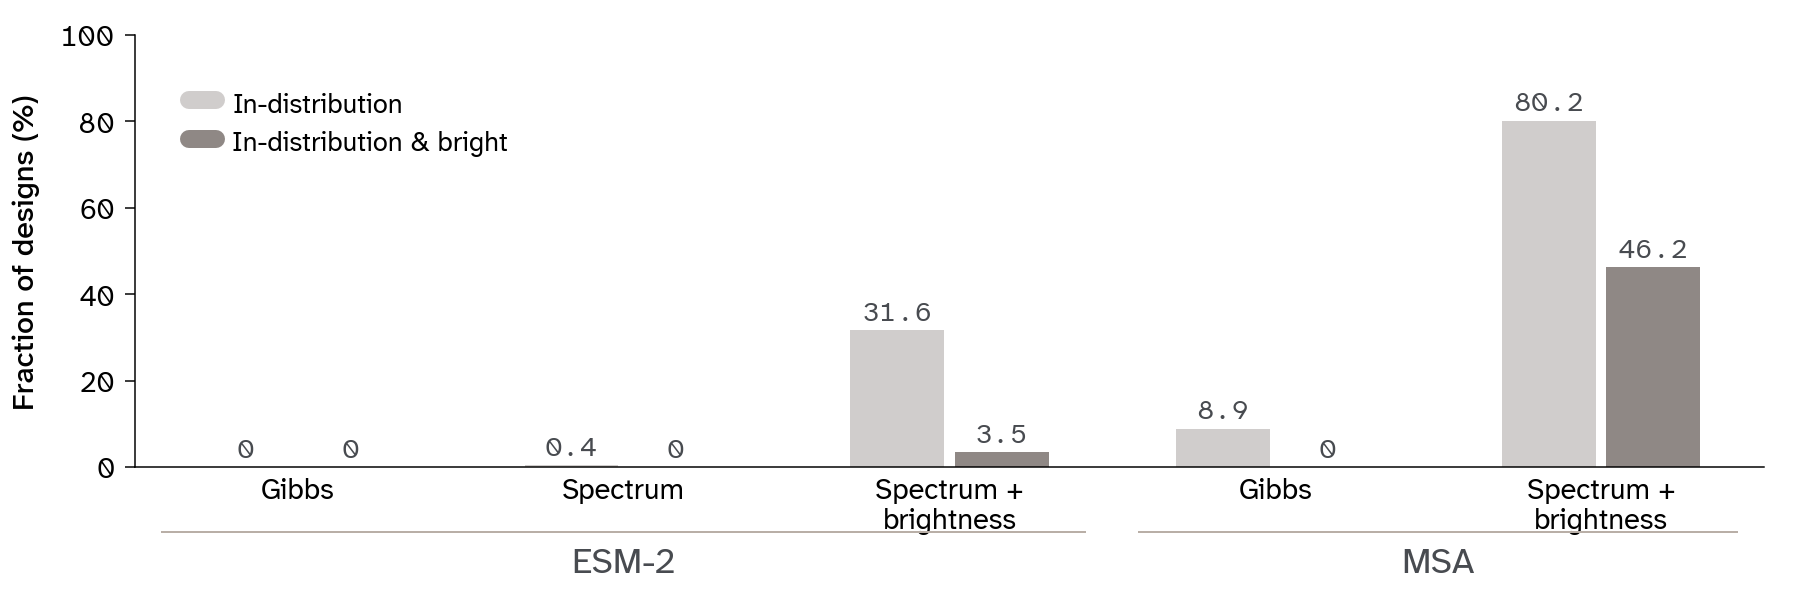

drawn: both targets pooled per strategy

                  strategy    n  id_pct  both_pct
               ESM-2 gibbs 1125    0.00      0.00
             Spectra guide 2250    0.36      0.00
Spectra + brightness guide 2400   31.62      3.46
                 MSA gibbs 1125    8.89      0.00
                 MSA guide 2250   80.18     46.22

                  strategy      target    n  n_uniq  id_pct  bright_pct  both_pct  k_id  k_bright  k_both  uniq_id_pct  uniq_both_pct  uniq_k_both
               ESM-2 gibbs target-free 1125    1125    0.00        0.00      0.00     0         0       0         0.00           0.00            0
             Spectra guide     mOrange 1125    1121    0.62        0.00      0.00     7         0       0         0.62           0.00            0
             Spectra guide        EBFP 1125    1123    0.09        0.00      0.00     1         0       0         0.09           0.00            0
Spectra + brightness guide     mOrange 1200    1008   33.83        3.4

In [5]:
def fig_bright(stem="bench_bright_fraction"):
    """Grouped bars: what share of each pool passes the deployability filters.

    One light / dark pair per strategy, with **both targets pooled** into it. The two gibbs
    strategies are target-free to begin with -- one run of 1,125 designs serves both targets -- and
    for the guided ones the question this figure asks is whether a selection rule produces
    deployable designs at all; the per-target split is printed below and quoted in the caption.
    Grey throughout: in this notebook colour belongs to the two reference proteins, not to a pool.
    """
    rows = []
    for st in ORDER:
        for t in ([None] if st in TARGET_FREE else TARGETS):
            d = D[(D.strategy == st) & (D.target == (t or TARGETS[0]))]
            u = UNIQ[(UNIQ.strategy == st) & (UNIQ.target == (t or TARGETS[0]))]
            rows.append(dict(strategy=st, target=t or "target-free", n=len(d), n_uniq=len(u),
                             id_pct=100 * d.is_id.mean(), bright_pct=100 * d.is_bright_conf.mean(),
                             both_pct=100 * d.is_ok.mean(), k_id=int(d.is_id.sum()),
                             k_bright=int(d.is_bright_conf.sum()), k_both=int(d.is_ok.sum()),
                             uniq_id_pct=100 * u.is_id.mean(),
                             uniq_both_pct=100 * u.is_ok.mean(), uniq_k_both=int(u.is_ok.sum())))
    R = pd.DataFrame(rows)

    # What the bars show: one row per strategy, both targets' raw pools together. A target-free
    # strategy is scored once rather than counted twice for designs it only ever generated once.
    P = pd.DataFrame([
        dict(strategy=st, n=len(d), id_pct=100 * d.is_id.mean(), both_pct=100 * d.is_ok.mean())
        for st in ORDER
        for d in [D[(D.strategy == st)
                    & (D.target.isin([TARGETS[0]] if st in TARGET_FREE else TARGETS))]]])

    fig, ax = plt.subplots(figsize=(0.9 * FULL_WIDE * PX, 300 * PX))
    fig.subplots_adjust(left=0.075, right=0.98, top=0.94, bottom=0.22)
    apc.mpl.style_plot(ax, monospaced_axes="y")
    strip_spines(ax)
    W = 0.32
    for _, r in P.iterrows():
        for dx, v, col in [(-W / 2, r.id_pct, tint(BAR_COLOR, 0.42)),
                           (W / 2, r.both_pct, BAR_COLOR)]:
            ax.bar(XPOS[r.strategy] + dx, v, width=W * 0.9, zorder=2, color=col)
            ax.text(XPOS[r.strategy] + dx, v + 1.5, f"{v:.1f}" if v else "0", ha="center",
                    va="bottom", zorder=4, **{**NUMBER_NOTE, "fontsize": 14})
    ax.set_xlim(-0.5, len(ORDER) - 0.5)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_ylabel("Fraction of designs (%)")
    family_axis(ax)
    ax.tick_params(axis="x", length=0)
    handles = [Line2D([], [], lw=9, color=c, label=lab) for lab, c in [
        ("in-distribution", tint(BAR_COLOR, 0.42)),
        ("in-distribution & bright", BAR_COLOR)]]
    leg = ax.legend(handles=handles, frameon=False, fontsize=13.5, loc="upper left",
                    handletextpad=0.6, labelspacing=0.4, borderaxespad=2)
    apc.mpl.capitalize_legend_text(leg)
    fig.savefig(f"{FIGDIR}/{stem}.svg")
    fig.savefig(f"{FIGDIR}/{stem}.png", dpi=200)
    plt.show()
    print("drawn: both targets pooled per strategy\n")
    print(P.round(2).to_string(index=False))
    print()
    return R


BRIGHT = fig_bright()
print(BRIGHT.round(2).to_string(index=False))
print("\n  *_pct / k_*      = share and count of the RAW pool (the equal budget) passing each filter;"
      "\n                    bright_pct is drawn nowhere -- see the note above."
      "\n  uniq_*           = the same shares among unique sequences, where a repeated draw cannot"
      "\n                    vote twice; the MSA guide's 1,125 draws are 675 (mOrange) and 738"
      "\n                    (EBFP) distinct designs.")

**Figure 1. The family profile is what puts designs inside the surrogate's tested region and the
brightness term is what makes any of them usable; only the MSA proposal does both, on either
target.** Share of each strategy's equal-budget pool that is in-distribution (light bar, ESM-2
max-pool nearest-neighbour distance to the 40,000-sequence GFP-DMS reference ≤ p99 = 30.21) and that
is in-distribution **and** confidently bright together (dark bar, logit > 0.5 — the bar the MSA
shortlists select on). Each bar pools both targets: 2,250 designs for `ESM-2 · Spectrum` and for
`MSA · Spectrum + brightness`, 2,400 for `ESM-2 · Spectrum + brightness` (1,200 per target from the
matched λ sweep) and 1,125 for each gibbs arm, whose single target-free run is scored once rather
than counted twice. Swapping ESM-2 for
the family profile raises the in-distribution share from 0.0 % to 8.9 % unguided, and from 0.4 %
(peaks only) or 31.6 % (peaks + brightness) to 81.0 % / 79.4 % (mOrange / EBFP, 80.2 % pooled)
guided, while brightness appears only where the objective asked for it: no design from either gibbs
arm or from the peaks-only `ESM-2 · Spectrum` guide clears logit > 0.5, on either target. Passing
both leaves 46.2 % of `MSA · Spectrum + brightness` — 585 mOrange and 455 EBFP designs, 52.0 % and
40.4 % — against 3.5 % for `ESM-2 · Spectrum + brightness` (20 and 63 designs, 1.7 % and 5.2 %), and
none at all for the other three. Rates are over the raw pool, in which a repeated sequence votes as
often as it was drawn.

## 3. Where the designs' peaks land, and the ten each strategy would put forward — mOrange

The two predicted peaks themselves, against the two references that bound the problem: the EGFP
scaffold each design started from (488 / 507 nm) and the target it was pointed at (548 / 562 nm),
both measured values from [`references/`](references/). One panel carries both layers of the
comparison:

- **The whole pool, in light grey.** A swarm rather than a summary: with ~1,125 designs per strategy
  the shape of the distribution is the finding — where the tails run, whether a column is one cloud
  or two, how much of it clears the target rule — and a box or a mean crossbar would replace exactly
  that with four numbers. The unit is the **unique** design: a swarm cannot place a duplicate
  anywhere but on top of itself, so plotting raw draws would silently overweight the strategies that
  repeat themselves.
- **The ten that strategy would actually put forward, in a darker grey**, on a mean ± 1 SD crossbar
  — at ten points a summary is readable instead of redundant. No campaign builds 1,125 constructs;
  the comparison that decides an order sheet is between each strategy's **best ten**, ranked by the
  surrogate's mean absolute error (MAE) to the target, `½(|Δex| + |Δem|)`.

Three rules pick the ten:

- **Deduplicate first.** A top ten drawn from raw output would repeat sequences.
- **Filter only the two strategies that were guided on brightness** — `ESM-2 · Spectrum +
  brightness` and `MSA · Spectrum + brightness` — on **both** shortlist criteria: in-distribution
  *and* `logit > 0.5`. These two were told to optimise a classifier score, so holding them to it is
  reading their own objective back; and the ID test is what says the surrogate ranking behind that
  score is interpolation rather than extrapolation.
- **Leave the other three unfiltered.** Neither gibbs arm nor the peaks-only spectrum guide was
  given a brightness term, and judging them on a criterion they never saw would measure the filter
  rather than the strategy. Their columns are their plain closest ten — which is also how the
  campaign builds their shortlists.

Five comparisons are drawn on each panel, as **Welch's t-test** between the two columns' tens
(unpaired, unequal variance — different designs, in numbers a filter can shorten and with spreads
that differ by an order of magnitude between a gibbs arm and a guided one):

- **every pair inside a proposal** — the three ESM-2 columns against each other, and the two MSA
  columns against each other — where the steering rule is the only thing that differs;
- **the two brightness-guided strategies against each other**, which is the one cross-proposal pair
  that holds the objective fixed and so isolates the proposal.

The remaining cross-proposal pairs change the proposal *and* the steering at once, so a difference
could not be attributed to either, and they are not tested. A bracket carries the raw *p* and is
drawn only where *p* < 0.05; Holm across each family of five, Mann-Whitney U as a distribution-free
check, and the same five comparisons on MAE — which the figure does not draw — are printed below.

The light layer is every strategy's pool **before** either filter, so for those two the ten are
drawn from a subset of the cloud behind them — 20 of 1,008 designs for `ESM-2 · Spectrum +
brightness` and 206 of 675 for `MSA · Spectrum + brightness` on mOrange. Figure 1 already carries
what fraction of each pool survives either filter, and Section 7 asks what the two filtered
strategies would look like without that treatment. A strategy with fewer than ten survivors
contributes what it has, with the count written under its column. Selection is the plain closest
ten, not the shortlists' greedy ≥ 5-residue-apart diverse ten; both are printed below, so the cost
of dropping the diversity rule stays visible.

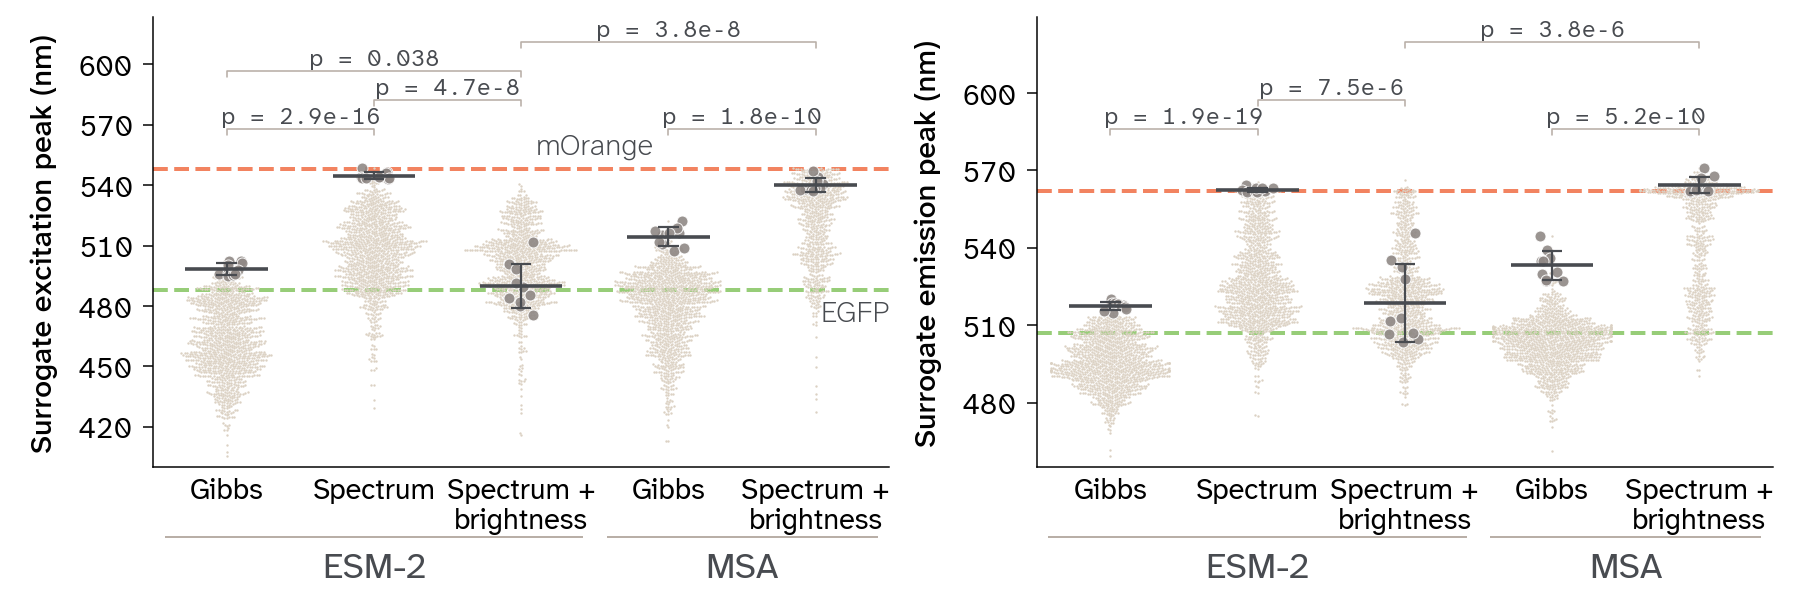

mOrange: unique designs, surrogate peaks (measured target 548 / 562 nm)

  excitation peak (nm)
                               n  median    min    max   IQR   mean    sd
strategy                                                                 
ESM-2 gibbs                 1125   462.3  405.8  502.6  28.1  463.0  17.9
Spectra guide               1121   507.8  429.5  548.3  25.4  506.4  18.4
Spectra + brightness guide  1008   501.0  416.0  540.6  24.3  499.7  18.7
MSA gibbs                   1125   482.8  412.8  522.2  24.5  479.0  18.3
MSA guide                    675   525.5  427.6  548.5  31.6  520.3  20.8

  emission peak (nm)
                               n  median    min    max   IQR   mean    sd
strategy                                                                 
ESM-2 gibbs                 1125   495.1  459.5  520.1  13.6  495.8   9.8
Spectra guide               1121   524.6  475.0  565.6  24.9  527.4  17.5
Spectra + brightness guide  1008   518.6  479.0  566.2  21.7  520.5 

In [6]:
from scipy.stats import mannwhitneyu, ttest_ind

POOL_SIZE, TOP_SIZE = 1.2, 5.5
# One tick step for all four panels of Figures 2 and 3. The panels cover different ranges, so
# letting matplotlib choose gives each one its own step (20 nm here, 25 there) and a distance read
# off one panel does not mean the same as the same distance read off the next.
Y_TICK_NM = 30
# The pool layer is ~6,700 markers per figure. As vector art that is what makes an Illustrator file
# slow to open and impossible to move around, so the swarms alone are rasterised INTO the SVG at
# this resolution; every other artist -- the ten, the crossbars, the rules, all type -- stays vector
# and stays editable. 600 dpi is ~4x the guide's 144 dpi working resolution, so the dots stay hard
# edged at print size.
RASTER_DPI = 600

# Where each reference's name goes, per target: (x in column units, which side of its own rule).
# Hand-picked empty spots rather than anything computed -- above the mOrange rule the panel is
# empty at every x; below 380 nm only the two ESM-2 columns reach, and neither reaches it at the
# left-hand end; the EGFP rule is crossed by every column, so its name goes where the nearest
# column is at its sparsest (the MSA guide's low tail on mOrange, the peaks-only guide's high tail
# on EBFP). Only the excitation panel is labelled; repeating the pair on the emission panel says
# nothing the first one has not.
RULE_LABEL = {"mOrange": {"target": (2.5, "above", "center"),
                          "scaffold": (4.5, "below", "right")},
              "EBFP": {"target": (0.0, "below", "center"),
                       "scaffold": (1.5, "above", "center")}}


def ref_rules(ax, kind, target, label=True):
    """The two references, drawn as dashed rules, named on the excitation panel only.

    Colour is what tells them apart -- the target in its own colour, the EGFP scaffold in green --
    so the names stay charcoal and sit clear of the swarms rather than beside the lines, where
    every column would be in the way.
    """
    for key, lab, val, col in [
            ("target", target,
             float(REF[target]["target_ex" if kind == "pred_ex" else "target_em"]),
             TARGET_COLOR[target]),
            ("scaffold", "EGFP",
             float(REF[target]["scaffold_ex" if kind == "pred_ex" else "scaffold_em"]),
             SCAFFOLD_COLOR)]:
        ax.axhline(val, color=col, lw=2, ls='--', zorder=-1)
        if not label:
            continue
        x, side, ha = RULE_LABEL[target][key]
        ax.annotate(lab, xy=(x, val), xytext=(0, 5 if side == "above" else -5),
                    textcoords="offset points", ha=ha,
                    va="bottom" if side == "above" else "top", zorder=6, **ANNOTATION)


# ---- the comparisons the figure makes ----------------------------------------------------------
# Every pair WITHIN a prior -- where the steering rule is the only thing that differs -- plus the one
# pair across priors that holds the steering fixed, the two brightness-guided strategies. The
# remaining cross-prior pairs change the proposal and the steering at once, so a difference could
# not be attributed to either and they are not tested.
PAIRS = [("ESM-2 gibbs", "Spectra guide"),
         ("ESM-2 gibbs", "Spectra + brightness guide"),
         ("Spectra guide", "Spectra + brightness guide"),
         ("MSA gibbs", "MSA guide"),
         ("Spectra + brightness guide", "MSA guide")]
ALPHA = 0.05


def welch(top, col):
    """Welch's t-test between each compared pair's ten designs, on one quantity.

    Unpaired and unequal-variance: the two columns are different designs, in numbers that a filter
    can shorten and with spreads that differ by an order of magnitude between a gibbs arm and a
    guided one. Mann-Whitney U is carried beside it as a distribution-free check, and Holm across
    the five comparisons guards the multiplicity; the panels annotate the RAW p, and only where it
    clears ALPHA, so an unbracketed pair is one the test could not separate.
    """
    out = {}
    for a, b in PAIRS:
        x = top.loc[top.strategy == a, col].to_numpy()
        y = top.loc[top.strategy == b, col].to_numpy()
        if len(x) < 2 or len(y) < 2:            # a filter can leave a column too short to test
            continue
        r = ttest_ind(x, y, equal_var=False)
        out[(a, b)] = dict(n_a=len(x), n_b=len(y), mean_a=x.mean(), mean_b=y.mean(),
                           diff=x.mean() - y.mean(), t=r.statistic, df=r.df, p=r.pvalue,
                           p_mwu=mannwhitneyu(x, y).pvalue)
    run = 0.0
    for rank, (p, ab) in enumerate(sorted((s["p"], ab) for ab, s in out.items())):
        run = max(run, min(1.0, (len(out) - rank) * p))
        out[ab]["p_holm"] = run
    return out


def p_text(p):
    """A p value in the notebook's mono note style: three decimals, or one significant exponent."""
    return f"p = {p:.3f}" if p >= 1e-3 else f"p = {p:.1e}".replace("e-0", "e-")


# A bracket's label is wider than the span it labels whenever the two columns are neighbours, so the
# label's own width is what the packing has to clear, in column units.
BR_LABEL_W, BR_LABEL_GAP = 1.05, 0.25


def bracket_levels(items):
    """Pack the brackets into as few levels as they fit in: shortest span first, lowest level that
    is horizontally free. Stacking one per comparison would spend four levels on five brackets that
    mostly do not overlap.

    `items` are `(key, x0, x1)` in axis units, so a figure that splits each strategy into two
    sub-columns can pack both halves into one stack.
    """
    rows, level = [], {}
    for key, x0, x1 in sorted(items, key=lambda it: (abs(it[2] - it[1]), min(it[1], it[2]))):
        lo, hi = sorted((x0, x1))
        mid = 0.5 * (lo + hi)
        lo, hi = min(lo, mid - 0.5 * BR_LABEL_W), max(hi, mid + 0.5 * BR_LABEL_W)
        for i, row in enumerate(rows):
            if all(hi + BR_LABEL_GAP <= l or lo >= h + BR_LABEL_GAP for l, h in row):
                break
        else:
            rows.append([])
            i = len(rows) - 1
        rows[i].append((lo, hi))
        level[key] = i
    return level, len(rows)


def draw_brackets(ax, marks, level, n_levels, base=None):
    """The significant comparisons, drawn over the two columns each one compares.

    `marks` are `(key, x0, x1, p, colour)`; only p < ALPHA is drawn, because a bracket is a claim
    and "we looked and found nothing" is the printout's job. `level` and `n_levels` are packed once
    for the whole figure, so a comparison keeps the same height everywhere it appears -- equal
    height means equal comparison, and a gap where a sibling panel has a bracket is a comparison
    that quantity could not separate. The stack sits above the headroom the panel already reserves,
    so nothing lands on a design or a reference label.
    """
    if not n_levels:
        return
    y0, y1 = ax.get_ylim()
    br0 = y1 if base is None else base                    # shared across panels when given
    rng = br0 - y0
    step, tick = 0.085 * rng, 0.018 * rng
    ax.set_ylim(y0, br0 + (n_levels - 1) * step + 0.075 * rng)
    for key, xa, xb, p, col in marks:
        if p >= ALPHA or key not in level:
            continue
        y = br0 + level[key] * step
        ax.plot([xa, xa, xb, xb], [y - tick, y, y, y - tick], color=col, lw=0.8, zorder=6)
        ax.annotate(p_text(p), xy=(0.5 * (xa + xb), y), xytext=(0, 1),
                    textcoords="offset points", ha="center", va="bottom",
                    **{**NUMBER_NOTE, "fontsize": 11.5})


def test_table(top, col):
    """One quantity's five comparisons, as a table."""
    s = welch(top, col)
    return pd.DataFrame(
        [{"comparison": f"{a} vs {b}", "mean_a": round(v["mean_a"], 2),
          "mean_b": round(v["mean_b"], 2), "diff": round(v["diff"], 2),
          "t": round(v["t"], 2), "df": round(v["df"], 1),
          "p": f"{v['p']:.2e}", "p_holm": f"{v['p_holm']:.2e}", "p_mwu": f"{v['p_mwu']:.2e}"}
         for (a, b), v in s.items()]).set_index("comparison")


def peaks_panel(ax, pool, top, kind, target, stats, level, n_levels, counts=False):
    """One peak, five strategies, two layers: the whole pool behind, the best ten in front.

    The pool is a swarm because with ~1,125 designs per strategy the shape of the distribution is
    the finding -- where the tails run, whether a column is one cloud or two, how much of it clears
    the target rule. The ten are a strip plus a mean ± 1 SD crossbar, because at ten points a
    summary is readable rather than a replacement for what it summarises.
    """
    drawn = {id(a) for a in ax.collections}
    sns.swarmplot(data=pool, x="strategy", y=kind, order=ORDER, ax=ax, linewidth=0, zorder=2,
                  color=POOL_COLOR, size=POOL_SIZE)
    # Rasterise what the swarm just added, and nothing else. Set on the collections rather than
    # passed to seaborn so it does not depend on which kwargs this seaborn version forwards.
    for coll in ax.collections:
        if id(coll) not in drawn:
            coll.set_rasterized(True)
    sns.stripplot(data=top, x="strategy", y=kind, order=ORDER, ax=ax, zorder=4, size=TOP_SIZE,
                  color=TOP_COLOR, jitter=0.11, alpha=0.9, linewidth=0.5, edgecolor="white")
    g = top.groupby("strategy")[kind]
    m, sd = g.mean(), g.std()
    for s in ORDER:
        if s not in m.index:                          # a filter can empty a column outright
            continue
        mean_sd_bar(ax, XPOS[s], m[s], sd.get(s, np.nan))
    apc.mpl.style_plot(ax, monospaced_axes="y")
    strip_spines(ax)
    ax.set_xlabel("")
    # A filter can leave a strategy with no designs at all; matplotlib autoscales to the artists
    # that exist, so the empty category has to be held on the axis explicitly.
    ax.set_xlim(-0.5, len(ORDER) - 0.5)
    n = top.groupby("strategy").size()
    extra = ({s: f"\n(best {int(n.get(s, 0))})" for s in ORDER if int(n.get(s, 0)) != 10}
             if counts else {})
    family_axis(ax, extra=extra, rule=-0.20 if extra else -0.155,
                text=-0.235 if extra else -0.19)
    ax.tick_params(axis="x", length=0)
    ax.set_ylabel(f"Surrogate {'excitation' if kind == 'pred_ex' else 'emission'} peak (nm)")
    # Both rules have to be on the axis for their labels to land anywhere, and the target one can
    # sit above every design.
    y0, y1 = ax.get_ylim()
    y1 = max(y1, float(REF[target]["target_ex" if kind == "pred_ex" else "target_em"]))
    ax.set_ylim(y0, y1 + 0.09 * (y1 - y0))
    draw_brackets(ax, [(ab, XPOS[ab[0]], XPOS[ab[1]], v["p"], NEUTRAL)
                       for ab, v in stats.items()], level, n_levels)   # can raise the panel top
    ax.yaxis.set_major_locator(MultipleLocator(Y_TICK_NM))
    # apc's monospaced_axes styles the tick-label artists that exist when it runs, so the mono
    # numerals have to be re-applied to the ticks this locator just replaced.
    apc.mpl.set_yticklabel_monospaced(ax)
    ref_rules(ax, kind, target, label=kind == "pred_ex")


def fig_peaks(pool, top, stem, target, counts=True):
    """Both peaks side by side, sized as two half_squares plus the gutter."""
    fig, axes = plt.subplots(1, 2, figsize=(0.9 * FULL_WIDE * PX, 300 * PX))
    # A shortened column adds a line under its tick label, which needs room the other case does not.
    n = top.groupby("strategy").size()
    short = counts and any(int(n.get(s, 0)) != 10 for s in ORDER)
    fig.subplots_adjust(left=0.085, right=0.985, top=0.97,
                        bottom=0.26 if short else 0.22, wspace=0.20)
    tests = {kind: welch(top, kind) for kind in ("pred_ex", "pred_em")}
    # One stack for the figure: a comparison significant on either peak is allotted a level, and
    # keeps it in both panels.
    level, n_levels = bracket_levels([(ab, XPOS[ab[0]], XPOS[ab[1]]) for ab in PAIRS
                                      if any(t.get(ab, {}).get("p", 1.0) < ALPHA
                                             for t in tests.values())])
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        for ax, kind in zip(axes, ("pred_ex", "pred_em")):
            peaks_panel(ax, pool, top, kind, target, tests[kind], level, n_levels, counts=counts)
    # dpi is what the rasterised swarms are rendered at; every other artist ignores it in an SVG.
    fig.savefig(f"{FIGDIR}/{stem}.svg", dpi=RASTER_DPI)
    fig.savefig(f"{FIGDIR}/{stem}.png", dpi=200)
    plt.show()
    # A swarm silently drops points it cannot place; say so rather than showing a thinned panel
    # as if it were the whole pool. Agg has nothing to rasterise INTO, so the PNG save and the
    # inline draw both announce that they ignored `set_rasterized` -- true, and about the backend
    # rather than the data, so it is not reported here. The SVG is where the flag does its work.
    for m in sorted({str(w.message) for w in caught if issubclass(w.category, UserWarning)
                     and not issubclass(w.category, DeprecationWarning)
                     and "will be ignored" not in str(w.message)}):
        print(f"  [{stem}] {m}")
    return tests


def pool_for(s, target, filtered=True):
    """One strategy's unique designs after the filters that apply to IT, for one target."""
    d = UNIQ[(UNIQ.strategy == s) & (UNIQ.target == target)]
    if filtered and s in GATED:
        d = d[d.is_id & d.is_bright_conf]
    return d


def top10(s, target, n=10, **kw):
    """The n closest designs of one strategy, out of whatever survives its filters."""
    return pool_for(s, target, **kw).nsmallest(n, "peak_err")


def n_mut(seqs):
    """Substitutions from the EGFP scaffold; designs only ever substitute inside the window."""
    return [sum(a != b for a, b in zip(x, SCAF)) for x in seqs]


def peaks_figure(target):
    """Figure 2 (mOrange) / Figure 3 (EBFP): every design's peaks, and the ten put forward."""
    pool = UNIQ[UNIQ.target == target]
    top = pd.concat([top10(s, target) for s in ORDER], ignore_index=True)
    top["n_mut"] = n_mut(top["designed_seq"])
    fig_peaks(pool, top, f"bench_peaks_{target}", target)

    # The pool: the whole distribution per strategy, one table per quantity. A swarm is drawn
    # precisely because five numbers do not stand in for it -- printing both keeps the figure's
    # claims checkable without reading positions off the panel.
    QUANTITY = [("pred_ex", "excitation peak (nm)"), ("pred_em", "emission peak (nm)"),
                ("peak_err", "MAE to the target (nm)")]

    def spread(d, col):
        g = d.groupby("strategy", sort=False)[col]
        return pd.DataFrame({"n": g.size(), "median": g.median(), "min": g.min(), "max": g.max(),
                             "IQR": g.quantile(0.75) - g.quantile(0.25), "mean": g.mean(),
                             "sd": g.std()}).round(1)

    print(f"{target}: unique designs, surrogate peaks (measured target "
          f"{TRUE_PEAKS[target][0]} / {TRUE_PEAKS[target][1]} nm)\n")
    for col, lab in QUANTITY:
        print(f"  {lab}")
        print(spread(pool, col).to_string(), end="\n\n")

    # The ten: mean ± 1 SD of the same three quantities, which is what the crossbar draws.
    print(f"{target}: best deployable ten per strategy -- unique designs ranked by surrogate MAE"
          f" to\nthe target, with in-distribution AND logit > {BRIGHT_T:g} required of the two"
          f" brightness-guided\nstrategies and no filter on the other three\n")
    g = top.groupby("strategy", sort=False)

    def pm(col, dp=1):
        m, sd = g[col].mean(), g[col].std()
        return pd.Series([f"{a:.{dp}f} ± {b:.{dp}f}" for a, b in zip(m, sd)], index=m.index)

    print(pd.DataFrame({"n": g.size(), "ex (nm)": pm("pred_ex"), "em (nm)": pm("pred_em"),
                        "MAE (nm)": pm("peak_err", 2), "best": g["peak_err"].min().round(2),
                        "blogit": g["pred_bright"].mean().round(2),
                        "idist": g["idist"].mean().round(2),
                        "n_mut": g["n_mut"].mean().round(1)}).to_string())
    print(f"\n{target}: Welch's t-test between the tens, {len(PAIRS)} comparisons per quantity"
          f" (Holm\nacross each family; the panels bracket the raw p, and only where p <"
          f" {ALPHA})\n")
    for col, lab in QUANTITY:
        print(f"  {lab}")
        print(test_table(top, col).to_string(), end="\n\n")

    print("  ex / em / MAE  = mean ± 1 SD across the ten, the crossbar the panel draws;"
          "\n                   best = the closest of the ten; n_mut = mean substitutions from"
          " EGFP;\n                   idist = mean NN distance to the 40k reference"
          " (in-distribution <= 30.21).")

    # What each rule costs, so none of the three is taken on faith.
    print("\n  pool size and best / mean MAE (nm) of the ten, by how the pool is filtered:")
    for s in ORDER:
        u = UNIQ[(UNIQ.strategy == s) & (UNIQ.target == target)]
        cols = []
        for lab, d in [("as drawn", pool_for(s, target)), ("ID only", u[u.is_id]),
                       ("bright only", u[u.is_bright_conf]), ("unfiltered", u)]:
            t = d.nsmallest(10, "peak_err")
            cols.append(f"{lab} n={len(d):4d} "
                        + (f"{t.peak_err.min():6.2f} /{t.peak_err.mean():7.2f}" if len(t)
                           else "     -- /     --"))
        p = pool_for(s, target)
        div = msc.diverse_topk(p, msc.N, msc.MIN_HD) if len(p) else None
        cols.append("diverse " + (f"{div.peak_err.min():6.2f} /{div.peak_err.mean():7.2f}"
                                  if div is not None and len(div) else "    -- /     --"))
        print(f"    {s:27} " + " | ".join(cols))
    return top


TOP_mOrange = peaks_figure("mOrange")

**Figure 2. The guided strategies move both peaks toward mOrange, and the ten each would put forward
separate them further: only the MSA proposal reaches the target while holding the brightness bar its
own objective implies.** Surrogate-predicted excitation (**left**) and emission (**right**) peak of
every unique mOrange design (light grey), by strategy, with each strategy's ten closest designs by
mean absolute error (MAE) drawn over them in darker grey on a mean ± 1 SD crossbar, against the
measured EGFP scaffold (488 / 507 nm, green dashed rule) and mOrange target (548 / 562 nm, orange
dashed rule). In the pool layer nothing is summarised: the two unguided strategies sit on the
scaffold (`ESM-2 · Gibbs` median 462.3 / 495.1 nm, `MSA · Gibbs` 482.8 / 503.8 nm) and the three
guided ones sit between it and the target, the MSA guide closest (median 525.5 / 551.0 nm, 1,125
draws over 675 unique designs). Every guided column also has an excitation tail running well below
the scaffold — to 429.5 nm for `ESM-2 · Spectrum` and 416.0 nm for `ESM-2 · Spectrum + brightness` —
so its mean sits below its median. The ten are picked after restricting the two brightness-guided
strategies to designs that are both in-distribution and confidently bright (logit > 0.5), leaving
pools of 20 and 206; the other three were given no brightness term and are ranked unfiltered. `MSA ·
Spectrum + brightness` averages 540.1 / 564.2 nm (best MAE 4.02 nm, mean logit +2.05, mean
nearest-neighbour distance 27.0) at 8.2 substitutions from EGFP, against 489.8 / 518.7 nm (best
31.80 nm) for the same objective on the ESM-2 proposal. The unfiltered `ESM-2 · Spectrum` guide is
the closest thing on the panel — 544.7 / 562.5 nm, best MAE 0.70 nm — at a mean brightness logit of
−13.3 and 20.5 substitutions, and the two gibbs arms land 26 – 44 nm short (498.3 / 517.4 nm ESM-2,
514.5 / 533.2 nm MSA), which is where the campaign's shortlisted gibbs controls come from. Brackets
are Welch's t-tests between the two columns' tens (n = 10 per group; five comparisons per peak —
every pair within a proposal, plus the two brightness-guided strategies against each other),
annotated with the raw *p* and drawn only where *p* < 0.05; Holm-adjusted *p*, Mann-Whitney U and
the same comparisons on MAE are printed below. On excitation all five separate: `MSA · Spectrum +
brightness` sits 50.3 nm above `ESM-2 · Spectrum + brightness` (*t*(10.6) = −13.9, *p* = 3.8 × 10⁻⁸)
and 25.6 nm above `MSA · Gibbs` (*t*(16.2) = −14.1, *p* = 1.8 × 10⁻¹⁰). On emission the brightness
term costs the ESM-2 proposal everything the spectrum guide gained — `ESM-2 · Spectrum + brightness`
is indistinguishable from `ESM-2 · Gibbs` (518.7 vs 517.4 nm, *t*(9.2) = −0.26, *p* = 0.80) — and
the same contrast in MAE is 50.8 vs 47.1 nm (*p* = 0.38), against 5.1 nm for the MSA guide (*t*(9.0)
= 11.8, *p* = 8.8 × 10⁻⁷).

## 4. The same two questions for EBFP

EBFP is the near target — 99.2 % identical to EGFP, 380 / 440 nm — and the scaffold starts 88.3 nm
away from it under the surrogate, against 56.7 nm for mOrange. Same pools, same filters, the same
figure, with the target rule in blue.

/home/ubuntu/miniconda3/envs/esm2-fp-design/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 11.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/home/ubuntu/miniconda3/envs/esm2-fp-design/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/home/ubuntu/miniconda3/envs/esm2-fp-design/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/home/ubuntu/miniconda3/envs/esm2-fp-design/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/home/ubuntu/miniconda3/envs/esm2-fp-design/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/home/ubuntu/miniconda3/envs/esm2-fp-design/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 11.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


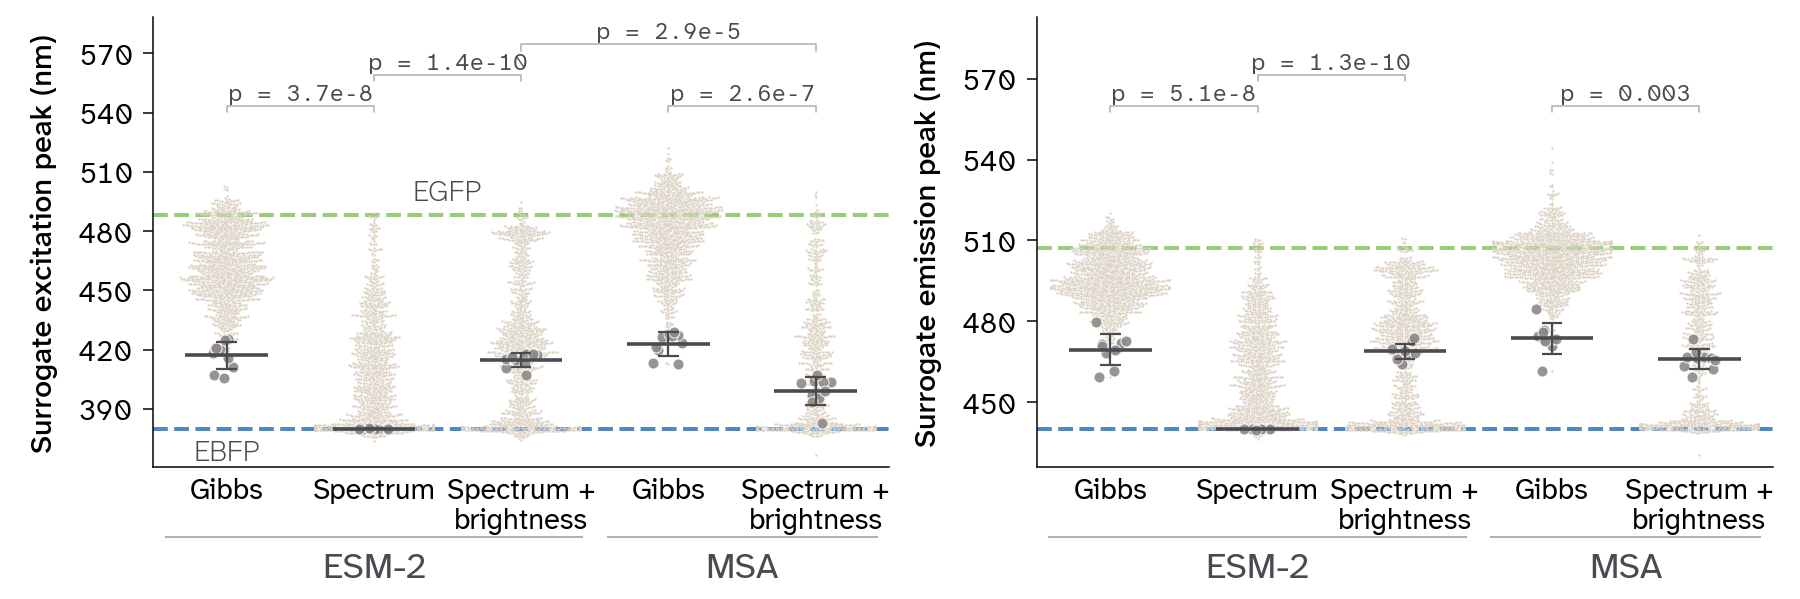

  [bench_peaks_EBFP] 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  [bench_peaks_EBFP] 11.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  [bench_peaks_EBFP] 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  [bench_peaks_EBFP] 7.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  [bench_peaks_EBFP] 7.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
EBFP: unique designs, surrogate peaks (measured target 380 / 440 nm)

  excitation peak (nm)
                               n  median    min    max   IQR   mean    sd
strategy                                                                 
ESM-2 gibbs                 1125   462.3  405.8  502.6  28.1  463.0  17.9
Spectra guide               1123   400.4  373.9  489.3  44

In [7]:
TOP_EBFP = peaks_figure("EBFP")

**Figure 3. Against the blue target the guided strategies reach it and overshoot, and the brightness
bar costs far more than it does on mOrange — only the MSA proposal pays it and still lands within 15
nm.** Surrogate-predicted excitation (**left**) and emission (**right**) peak of every unique EBFP
design (light grey), by strategy, with each strategy's ten closest designs by mean absolute error
(MAE) over them in darker grey on a mean ± 1 SD crossbar, drawn and filtered exactly as Figure 2,
against the measured EGFP scaffold (488 / 507 nm, green dashed rule) and EBFP target (380 / 440 nm,
blue dashed rule). The two gibbs columns are the same target-free designs as Figure 2 — medians
462.3 / 495.1 nm (`ESM-2 · Gibbs`) and 482.8 / 503.8 nm (`MSA · Gibbs`), 80 – 100 nm above the
target on excitation — while the three guided strategies sit on or past it: `ESM-2 · Spectrum`
median 400.4 / 457.2 nm, `MSA · Spectrum + brightness` 404.6 / 465.2 nm, `ESM-2 · Spectrum +
brightness` 417.9 / 470.9 nm, with excitation running down to 373.9 nm and 366.8 nm respectively,
i.e. **past** the target rather than short of it — the opposite tail from mOrange, where every
strategy fell short. Among the ten, `MSA · Spectrum + brightness` averages 399.0 / 465.9 nm (best
MAE 14.62 nm, mean logit +3.65, mean nearest-neighbour distance 22.0) at 7.4 substitutions from
EGFP, from a surviving pool of 153; `ESM-2 · Spectrum + brightness` reaches 414.7 / 468.9 nm (best
29.30 nm) from a pool of 55. The unfiltered `ESM-2 · Spectrum` guide sits **on** the target — 380.0
/ 440.0 nm, best MAE 0.01 nm — at a mean brightness logit of −11.0, and the two gibbs arms land at
417.1 / 469.5 nm (ESM-2, best 24.40 nm) and 422.8 / 473.7 nm (MSA, best 27.10 nm). Brackets are the
same five Welch's t-tests as Figure 2, drawn on the same levels and only where *p* < 0.05. On EBFP
the two ESM-2 arms that were not given a spectrum-only objective are indistinguishable on both peaks
(excitation 417.1 vs 414.7 nm, *t*(13.2) = 0.97, *p* = 0.35; emission 469.5 vs 468.9 nm, *t*(13.3) =
0.31, *p* = 0.76), and the cross-proposal pair separates on excitation (15.7 nm, *t*(12.9) = 6.27,
*p* = 2.9 × 10⁻⁵) but not on emission (3.0 nm, *t*(16.8) = 1.99, *p* = 0.064) — the MSA guide's
advantage here is 9.3 nm of MAE (22.5 vs 31.8 nm, *t*(11.3) = 6.74, *p* = 2.8 × 10⁻⁵).

## 5. The two targets, a panel each — what the best ten actually achieve

Figures 2 and 3 carry the MAE only as the distance between a crossbar and a rule, and one target
each. This is the same ten designs per strategy, drawn as the quantity they were **ranked** on,
`½(|Δex| + |Δem|)`, and laid out as those two figures are: two panels, one target each, on a shared
y axis, so a strategy's two campaigns can be read against each other and a nanometre means the same
thing in both. **Orange is mOrange, blue is EBFP**, the hues those figures give their target rules.
Same x axis, same strip-plus-crossbar, same filters: the two brightness-guided strategies restricted
to in-distribution and confidently bright, the other three unfiltered. The five comparisons of
Figures 2 and 3 are run again here, on MAE and **within each target**, and bracketed in that
target's colour: comparing across the two would ask whether 548 nm is further from EGFP than 380 nm
is, which is a property of the targets rather than of any strategy.

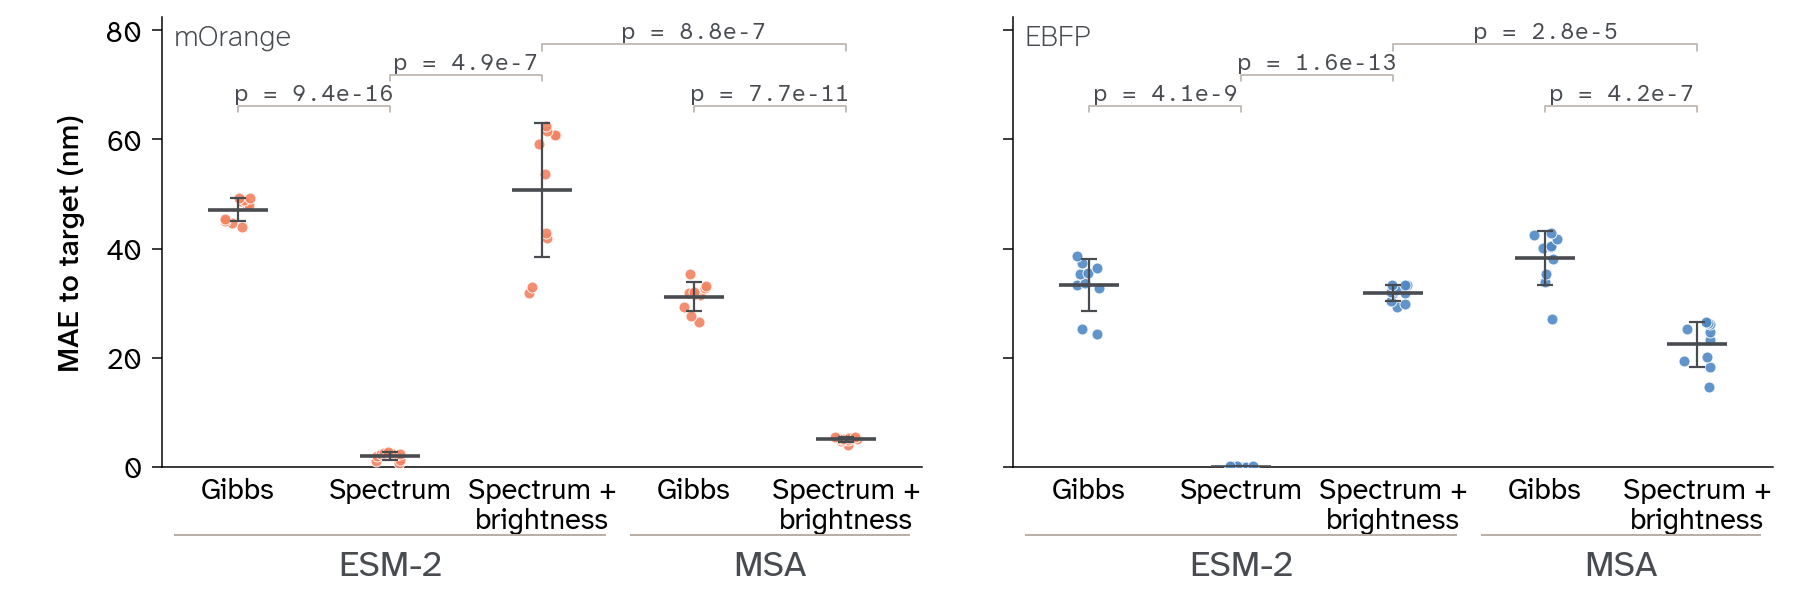

best ten per strategy and target, surrogate MAE (nm) -- the same designs Figures 2 and 3
draw, under the same filters

                             mean            sd           best        
target                       EBFP mOrange  EBFP mOrange   EBFP mOrange
strategy                                                              
ESM-2 gibbs                 33.29   47.11  4.80    2.11  24.40   43.85
Spectra guide                0.07    2.01  0.04    0.75   0.01    0.70
Spectra + brightness guide  31.78   50.76  1.48   12.26  29.30   31.80
MSA gibbs                   38.24   31.16  4.89    2.64  27.10   26.50
MSA guide                   22.47    5.07  4.12    0.43  14.62    4.02

  Welch's t-test on MAE within each target, the same five comparisons Figures 2 and 3
  bracket on the peaks (Holm across each family of five):

  mOrange
                                             mean_a  mean_b   diff      t    df         p    p_holm     p_mwu
comparison                                     

In [8]:
def fig_mae(stem="bench_top10_mae"):
    """Each strategy's best ten, one target per panel: strip plus mean ± 1 SD crossbar.

    Laid out as Figures 2 and 3 are -- two panels side by side, the same five columns under the same
    two-level axis -- but the panels are the two TARGETS rather than the two peaks, and the quantity
    is the surrogate MAE the ten were ranked on, which those figures carry only as the distance
    between a crossbar and a rule. Colour names the target, as it does on their reference rules.
    **One y axis for both panels**: a nanometre means the same thing on either target, so the two
    campaigns are read against each other rather than each against its own scale.
    """
    fig, axes = plt.subplots(1, 2, figsize=(0.9 * FULL_WIDE * PX, 300 * PX), sharey=True)
    fig.subplots_adjust(left=0.09, right=0.985, top=0.97, bottom=0.22, wspace=0.12)
    rng = np.random.default_rng(RNG_SEED)
    HALF = 0.2
    TOPS = {TARGETS[0]: TOP_mOrange, TARGETS[1]: TOP_EBFP}

    # The same five comparisons as Figures 2 and 3, run WITHIN a target -- across the two would ask
    # whether 548 nm is further from EGFP than 380 nm is, which is a property of the targets and not
    # of any strategy. The stack is packed once for the figure, so a comparison keeps its height in
    # both panels and a gap is a comparison that target could not separate.
    tests = {t: welch(TOPS[t], "peak_err") for t in TARGETS}
    level, n_levels = bracket_levels([(ab, XPOS[ab[0]], XPOS[ab[1]]) for ab in PAIRS
                                      if any(tests[t].get(ab, {}).get("p", 1.0) < ALPHA
                                             for t in TARGETS)])
    # One base for both panels, from the tallest design in either: with a shared y axis the brackets
    # have to start above the data of BOTH, or the second panel's stack would climb over the first's.
    base = 1.06 * max(TOPS[t].peak_err.max() for t in TARGETS)

    rows = []
    for ax, t in zip(axes, TARGETS):
        top = TOPS[t]
        for s in ORDER:
            v = top.loc[top.strategy == s, "peak_err"].to_numpy()
            if not len(v):                                # a filter can empty a column outright
                continue
            ax.plot(XPOS[s] + rng.uniform(-0.09, 0.09, len(v)), v, ls="none", marker="o",
                    ms=TOP_SIZE, color=TARGET_COLOR[t], mec="white", mew=0.5, alpha=0.9, zorder=3)
            m, sd = v.mean(), v.std(ddof=1)
            mean_sd_bar(ax, XPOS[s], m, sd, half=HALF, zorder=4)
            rows.append(dict(strategy=s, target=t, n=len(v), mean=round(m, 2), sd=round(sd, 2),
                             best=round(v.min(), 2), worst=round(v.max(), 2)))
        apc.mpl.style_plot(ax, monospaced_axes="y")
        strip_spines(ax)
        ax.set_xlim(-0.5, len(ORDER) - 0.5)
        ax.set_ylim(0, base)                              # an MAE cannot be negative
        draw_brackets(ax, [(ab, XPOS[ab[0]], XPOS[ab[1]], v["p"], NEUTRAL)
                           for ab, v in tests[t].items()], level, n_levels, base=base)
        family_axis(ax)
        ax.tick_params(axis="x", length=0)
        # The target names the panel, at the top left: the tallest bracket spans the right-hand half
        # in both panels, and a key would be one entry long and say the same thing twice.
        ax.annotate(t, xy=(0.015, 0.985), xycoords="axes fraction", ha="left", va="top",
                    **ANNOTATION)
    axes[0].set_ylabel("MAE to target (nm)")
    fig.savefig(f"{FIGDIR}/{stem}.svg")
    fig.savefig(f"{FIGDIR}/{stem}.png", dpi=200)
    plt.show()
    return pd.DataFrame(rows)


MAE_TOPS = {TARGETS[0]: TOP_mOrange, TARGETS[1]: TOP_EBFP}
MAE10 = fig_mae()
print("best ten per strategy and target, surrogate MAE (nm) -- the same designs Figures 2 and 3"
      "\ndraw, under the same filters\n")
print(MAE10.pivot(index="strategy", columns="target",
                  values=["mean", "sd", "best"]).reindex(ORDER).to_string())

print("\n  Welch's t-test on MAE within each target, the same five comparisons Figures 2 and 3"
      "\n  bracket on the peaks (Holm across each family of five):\n")
for t in TARGETS:
    print(f"  {t}")
    print(test_table(MAE_TOPS[t], "peak_err").to_string(), end="\n\n")

print("  the gap between the two targets, per strategy (mean MAE, EBFP - mOrange):")
g = MAE10.pivot(index="strategy", columns="target", values="mean").reindex(ORDER)
for s in ORDER:
    print(f"    {s:27} {g.loc[s, TARGETS[0]]:6.2f} -> {g.loc[s, TARGETS[1]]:6.2f} nm"
          f"  ({g.loc[s, TARGETS[1]] - g.loc[s, TARGETS[0]]:+6.2f})")

**Figure 4. Under the brightness bar the near target is the harder one — the MSA proposal lands 5.1
nm from mOrange but 22.5 nm from EBFP, and it is still the only guided strategy that carries the bar
and arrives on either.** Surrogate MAE to the target, `½(|Δex| + |Δem|)`, of each strategy's ten
closest unique designs, for mOrange (**left**, orange) and EBFP (**right**, blue) on one shared y
axis, with the mean ± 1 SD crossbar; the same designs and the same filters as Figures 2 and 3. `MSA
· Spectrum + brightness` averages 5.07 ± 0.43 nm on mOrange against 22.47 ± 4.12 nm on EBFP (best
4.02 and 14.62 nm), while `ESM-2 · Spectrum + brightness`, the same objective on the other proposal,
sits at 50.76 ± 12.26 and 31.78 ± 1.48 nm — worse than its own unguided control on mOrange (`ESM-2 ·
Gibbs`, 47.11 ± 2.11 nm). The peaks-only `ESM-2 · Spectrum` guide is closer than anything on both
targets (2.01 ± 0.75 and 0.07 ± 0.04 nm) and carries no brightness term at all; the two gibbs arms
bracket the middle at 47.11 / 33.29 nm (ESM-2) and 31.16 / 38.24 nm (MSA). Every ESM-2 arm lands
closer on EBFP than on mOrange (by 1.94 – 18.98 nm) while both MSA arms land further (by 7.08 and
17.40 nm), so the MSA guide's margin over the same objective on the ESM-2 proposal narrows from
45.69 nm on mOrange to 9.32 nm on EBFP (Welch, *p* = 8.8 × 10⁻⁷ and 2.8 × 10⁻⁵, printed below).
Brackets are those five Welch's t-tests run within each target, in that target's colour, drawn only
where *p* < 0.05. One comparison fails on both: `ESM-2 · Gibbs` against `ESM-2 · Spectrum +
brightness` (mOrange −3.65 nm, *t*(9.5) = −0.93, *p* = 0.38; EBFP +1.50 nm, *t*(10.7) = 0.95, *p* =
0.37) — under the brightness bar the ESM-2 proposal's guided output is not distinguishable from its
own unguided control, on either target. The MSA guide beats its own control by 26.10 nm on mOrange
(*t*(9.5) = 30.89, *p* = 7.7 × 10⁻¹¹) and 15.77 nm on EBFP (*t*(17.5) = 7.81, *p* = 4.2 × 10⁻⁷).

## 6. The same juxtaposition on the two peaks

Figure 4 puts the two campaigns side by side on the quantity the ten were ranked on. This puts them
side by side on the peaks themselves, where each has its own rule to be read against: **orange is
the mOrange campaign, blue is the EBFP campaign**, each strategy contributing one pair of columns,
and three references per panel — the two targets in their own colours and the EGFP scaffold in
green. Both layers of Figures 2 and 3 come along, as a **raincloud**: the whole unique pool of that
strategy and campaign as a half violin on the left of its sub-column, and the same ten as Figures 2
– 4 — under the same filters — as rain on the right, with the mean ± 1 SD crossbar over them. The
two gibbs arms are target-free — one pool, ranked twice — so they carry a single grey violin with
both tens raining onto the same baseline over it. A density rather than the swarm those figures use:
at half a column each, a swarm cannot place a third of the designs, and 1,125 jittered dots only
draw the range. No significance brackets here: every comparison that matters is within one campaign,
and Figures 2 and 3 draw and print those.

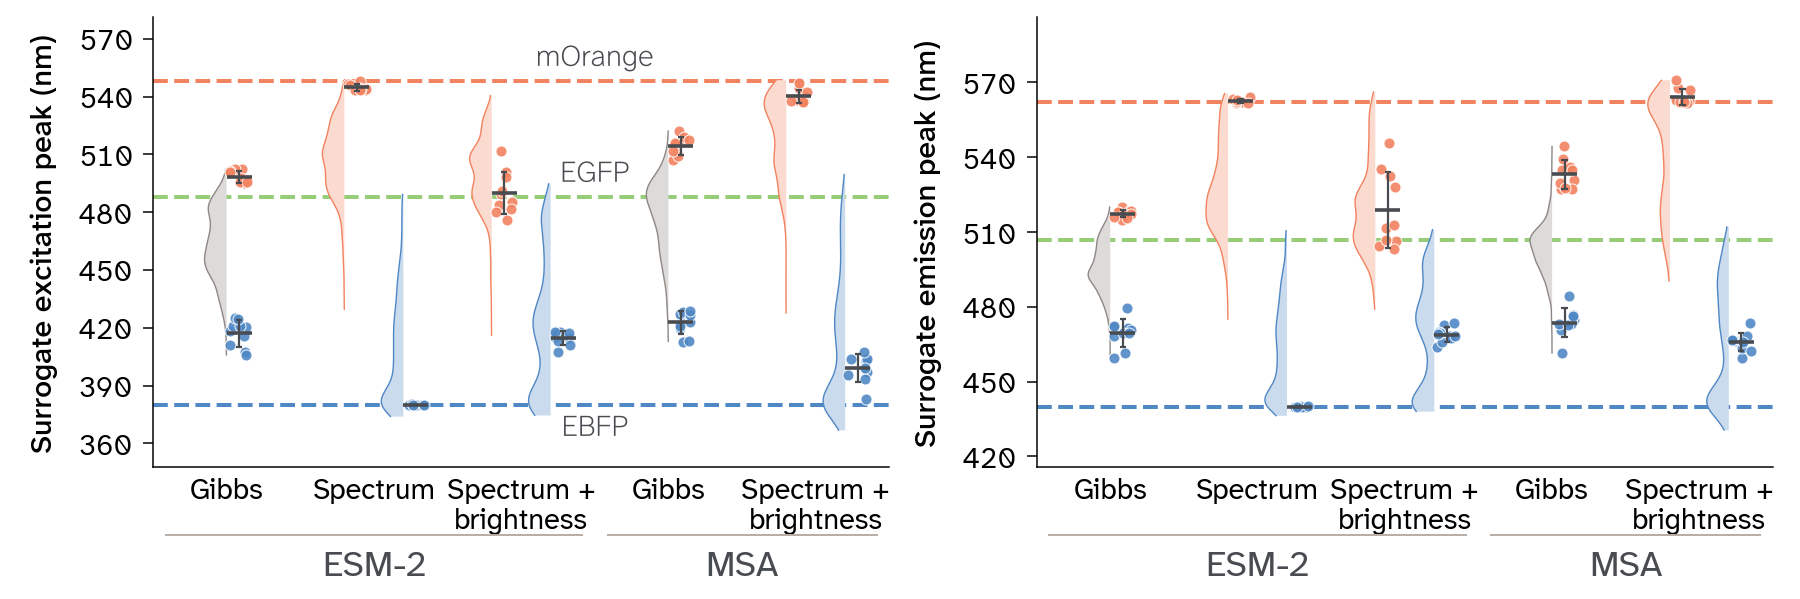

best ten per strategy and target, surrogate peaks (nm, mean ± 1 SD across the ten) --
the same designs Figure 4 measures the MAE of

peak                             pred_ex                    pred_em             
target                           mOrange         EBFP       mOrange         EBFP
strategy                                                                        
ESM-2 gibbs                  498.3 ± 3.0  417.1 ± 6.9   517.4 ± 1.6  469.5 ± 5.7
Spectra guide                544.7 ± 1.7  380.0 ± 0.1   562.5 ± 0.8  440.0 ± 0.1
Spectra + brightness guide  489.8 ± 11.0  414.7 ± 3.4  518.7 ± 15.2  468.9 ± 2.9
MSA gibbs                    514.5 ± 4.7  422.8 ± 6.0   533.2 ± 5.7  473.7 ± 5.7
MSA guide                    540.1 ± 3.3  399.0 ± 7.1   564.2 ± 3.1  465.9 ± 3.7

  and the pool each ten was drawn from -- median of all unique designs (n in brackets):

peak                             pred_ex                     pred_em              
target                           mOrange      

In [9]:
from matplotlib import patheffects
from scipy.stats import gaussian_kde

# With a pool behind every sub-column there is no gap wide enough for a word, so the three names sit
# in the middle of the panel over a white halo -- the cloud is light enough to read through, and the
# alternative (labels outside the axes) costs both panels a right-hand margin.
HALO = [patheffects.withStroke(linewidth=3, foreground="white")]
VIOLIN_W, RAIN_PAD, RAIN_W = 0.15, 0.02, 0.13


def half_violin(ax, x, v, color, width=VIOLIN_W, n=200):
    """Density of `v`, drawn to the LEFT of `x` only -- the raincloud helper of
    `../in-silico-test/visualization_task2.ipynb`, under the same two rules.

    Evaluated between the group's own extremes (seaborn's `cut=0` convention), so the violin never
    claims designs where there are none, and scaled to a fixed maximum width, so two clouds are read
    against each other by shape rather than by area. The curved side is stroked and the flat side is
    not: a rule down the column's own position would read as an axis rather than as an edge.
    """
    if len(v) < 3 or np.ptp(v) == 0:                      # nothing for a density to describe
        return
    grid = np.linspace(v.min(), v.max(), n)
    dens = gaussian_kde(v)(grid)
    dens = dens / dens.max() * width
    ax.fill_betweenx(grid, x - dens, x, facecolor=tint(color, 0.30), edgecolor="none", zorder=2)
    ax.plot(x - dens, grid, color=color, lw=0.7, zorder=2)
RULE_LABEL5 = {"pred_ex": {"mOrange": "above", "EBFP": "below", "EGFP": "above"},
               "pred_em": {"mOrange": "above", "EBFP": "below", "EGFP": "above"}}
RULE_X5 = 2.5


def fig_peaks_targets(stem="bench_top10_peaks"):
    """The best ten's two peaks with both campaigns on one axis: excitation left, emission right.

    Figure 4 juxtaposes the two targets on the quantity the ten were ranked on; this does it on the
    peaks themselves, where each campaign has its own rule to be read against and the two sit in
    different regions of the spectrum. Three references per panel -- the two targets in their own
    colours, the EGFP scaffold in green -- and no significance brackets: every comparison that
    matters here is within one campaign, and Figures 2 and 3 draw those already.
    """
    fig, axes = plt.subplots(1, 2, figsize=(0.9 * FULL_WIDE * PX, 300 * PX))
    fig.subplots_adjust(left=0.085, right=0.985, top=0.97, bottom=0.22, wspace=0.20)
    rng = np.random.default_rng(RNG_SEED)
    DX = 0.2
    rows = []
    for ax, kind in zip(axes, ("pred_ex", "pred_em")):
        for st in ORDER:
            # A target-free strategy drew ONE pool that both campaigns then ranked, so it gets one
            # violin -- in the warm grey Figure 1 gives those arms, since the encoded variable is
            # absent rather than taking a third value -- and both tens rain onto the same baseline
            # over it. A guided strategy has a genuine pool per campaign, so it keeps two.
            free = st in TARGET_FREE
            if free:
                c = UNIQ[(UNIQ.strategy == st) & (UNIQ.target == TARGETS[0])][kind].to_numpy()
                half_violin(ax, XPOS[st], c, BAR_COLOR)
                at = {t: XPOS[st] for t in TARGETS}
            else:
                at = {TARGETS[0]: XPOS[st] - DX, TARGETS[1]: XPOS[st] + DX}
                for t in TARGETS:
                    c = UNIQ[(UNIQ.strategy == st) & (UNIQ.target == t)][kind].to_numpy()
                    half_violin(ax, at[t], c, TARGET_COLOR[t])
            for t in TARGETS:
                pool = UNIQ[(UNIQ.strategy == st) & (UNIQ.target == t)]
                top = MAE_TOPS[t]
                v = top.loc[top.strategy == st, kind].to_numpy()
                if not len(v):                            # a filter can empty a column outright
                    continue
                x = at[t]
                ax.plot(x + RAIN_PAD + rng.uniform(0, RAIN_W, len(v)), v, ls="none", marker="o",
                        ms=TOP_SIZE, color=TARGET_COLOR[t], mec="white", mew=0.5, alpha=0.9,
                        zorder=4)
                mean_sd_bar(ax, x + RAIN_PAD + 0.5 * RAIN_W, v.mean(), v.std(ddof=1),
                            half=0.5 * RAIN_W + 0.02, zorder=5)
                rows.append(dict(strategy=st, target=t, peak=kind, n_pool=len(pool),
                                 pool_med=round(float(pool[kind].median()), 1),
                                 mean=round(v.mean(), 1), sd=round(v.std(ddof=1), 1)))
        apc.mpl.style_plot(ax, monospaced_axes="y")
        strip_spines(ax)
        ax.set_xlim(-0.5, len(ORDER) - 0.5)
        ax.set_ylabel(f"Surrogate {'excitation' if kind == 'pred_ex' else 'emission'} peak (nm)")
        col = "target_ex" if kind == "pred_ex" else "target_em"
        refs = [(t, float(REF[t][col]), TARGET_COLOR[t]) for t in TARGETS]
        refs.append(("EGFP", float(REF[TARGETS[0]]["scaffold_ex" if kind == "pred_ex"
                                                   else "scaffold_em"]), SCAFFOLD_COLOR))
        # Room for the three rules and for the name of whichever one sits highest.
        y0, y1 = ax.get_ylim()
        y0, y1 = min([y0] + [v for _, v, _ in refs]), max([y1] + [v for _, v, _ in refs])
        ax.set_ylim(y0 - 0.06 * (y1 - y0), y1 + 0.13 * (y1 - y0))
        for lab, val, c in refs:
            ax.axhline(val, color=c, lw=2, ls="--", zorder=-1)
            if kind == 'pred_ex':
                side = RULE_LABEL5[kind][lab]
                ax.annotate(lab, xy=(RULE_X5, val), xytext=(0, 5 if side == "above" else -5),
                            textcoords="offset points", ha="center",
                            va="bottom" if side == "above" else "top", zorder=6,
                            path_effects=HALO, **ANNOTATION)
        ax.yaxis.set_major_locator(MultipleLocator(Y_TICK_NM))
        apc.mpl.set_yticklabel_monospaced(ax)
        family_axis(ax)
        ax.tick_params(axis="x", length=0)
    # Nothing here is a 1,000-marker layer, so the whole figure stays vector.
    fig.savefig(f"{FIGDIR}/{stem}.svg")
    fig.savefig(f"{FIGDIR}/{stem}.png", dpi=200)
    plt.show()
    return pd.DataFrame(rows)


PEAKS10 = fig_peaks_targets()
print("best ten per strategy and target, surrogate peaks (nm, mean ± 1 SD across the ten) --"
      "\nthe same designs Figure 4 measures the MAE of\n")
print(PEAKS10.assign(v=lambda d: d["mean"].map("{:.1f}".format) + " ± " + d.sd.map("{:.1f}".format))
      .pivot(index="strategy", columns=["peak", "target"], values="v").reindex(ORDER).to_string())
print("\n  and the pool each ten was drawn from -- median of all unique designs (n in brackets):\n")
print(PEAKS10.assign(v=lambda d: d.pool_med.map("{:.1f}".format) + " (" + d.n_pool.astype(str) + ")")
      .pivot(index="strategy", columns=["peak", "target"], values="v").reindex(ORDER).to_string())
print("\n  the measured references: mOrange 548 / 562 nm, EBFP 380 / 440 nm,"
      " EGFP scaffold 488 / 507 nm.")

**Figure 5. The same ten designs on the two peaks, both campaigns at once: only the peaks-only guide
lands on a target rule, and only the MSA guide approaches one while carrying the brightness bar.**
Surrogate-predicted excitation (**left**) and emission (**right**) peak of each strategy's ten
closest unique designs, orange for the mOrange campaign and blue for the EBFP campaign, with the
mean ± 1 SD crossbar, drawn as rain to the right of a half violin of that campaign's whole unique
pool — 1,125 designs for the gibbs arms, 1,008 – 1,123 for the ESM-2 guides, 675 (mOrange) and 738
(EBFP) for the MSA guide, all before either filter, each density evaluated only between its own
extremes and scaled to a fixed width, so two clouds are compared by shape rather than by area. The
three dashed rules are the two measured targets in their own colours (mOrange 548 / 562 nm, EBFP 380
/ 440 nm) and the EGFP scaffold in green (488 / 507 nm). The same designs and the same filters as
Figures 2 – 4. `ESM-2 · Spectrum` sits on both rules it was pointed at — 544.7 ± 1.7 / 562.5 ± 0.8
nm on mOrange and 380.0 ± 0.1 / 440.0 ± 0.1 nm on EBFP — with no brightness term to carry. `MSA ·
Spectrum + brightness` reaches 540.1 ± 3.3 / 564.2 ± 3.1 nm on mOrange and stops 19.0 / 25.9 nm
short on EBFP (399.0 ± 7.1 / 465.9 ± 3.7 nm). `ESM-2 · Spectrum + brightness` never leaves the
scaffold's neighbourhood on mOrange (489.8 ± 11.0 / 518.7 ± 15.2 nm, the widest spread on either
panel) and lands with the gibbs arms on EBFP (414.7 ± 3.4 / 468.9 ± 2.9 nm against 417.1 / 469.5 nm
for `ESM-2 · Gibbs`). Read across a strategy's two columns, every EBFP ten sits below the scaffold
rule and every mOrange ten at or above it: one scaffold, two directions. The two gibbs columns carry
one grey violin apiece rather than two coloured ones: those runs are target-free, so both campaigns
ranked the same 1,125 designs, and their two tens rain onto the same baseline over it. On mOrange
the MSA guide's ten sit well into its pool's upper tail (540.1 / 564.2 nm against pool medians of
525.5 / 551.0 nm); on EBFP they sit almost at the median (399.0 / 465.9 against 404.6 / 465.2 nm),
because the two filters have already cut that pool to 153 designs before the ranking starts.

## 7. Why the best designs are not the ones sitting on the target

Figures 2 and 3 show designs sitting exactly on the target rules — 113 of the MSA guide's 675 unique
mOrange designs land within 1 nm of 562 nm emission, and 127 of its 738 EBFP designs within 1 nm of
440 nm — and its best design is 0.07 nm (mOrange) and 0.05 nm (EBFP) from the target on the mean of
both peaks. Their best-ten layers pick designs 4 – 5 nm and 15 nm out. The gap is not a selection bug; it
is the brightness term, and this section is the arithmetic of that.

Ranking each strategy's pool on surrogate MAE **alone** — no ID test, no brightness — gives the first
table below. Those designs are much closer to the target, and essentially none of them is
deployable: the classifier calls **0 of the 50** confidently bright on either target, and only 6
(mOrange) and 4 (EBFP) of the 50 are in-distribution. Inside the MSA guide's pool the two quantities
are positively correlated — Pearson r = 0.32 (mOrange) and 0.51 (EBFP) between brightness logit and
MAE — so the closer a design gets to the target, the dimmer the classifier says it is. The gate costs
3.95 nm on mOrange and 14.57 nm on EBFP, and that is not slack in the search: it is the price of the
only constraint that has ever correlated with a protein actually working.

The second effect is smaller and worth naming separately: MAE couples the two peaks, so a design
sitting on the emission rule need not be close overall. Of the 113 mOrange designs within 1 nm of
562 nm emission, the median excitation error is 9.1 nm, and only 23 designs in that pool are within
2 nm on **both** peaks. On EBFP the two peaks move together far more tightly — median excitation
error 0.5 nm for the designs on the emission rule, and 175 designs within 2 nm on both — and **0 of
those 175 are confidently bright**, which is the whole of the story on that target.

In [10]:
# The same ranking with every filter removed. Not drawn: it would be the best-ten layer of Figures 2 and 3 with the two
# filtered columns moved, and the numbers are the point.
for target in TARGETS:
    raw10 = pd.concat([top10(s, target, filtered=False) for s in ORDER], ignore_index=True)
    raw10["n_mut"] = n_mut(raw10["designed_seq"])
    print(f"=== {target}: best ten per strategy ranked on surrogate MAE ALONE "
          f"(no ID test, no brightness gate)\n")
    print(raw10.groupby("strategy", sort=False).agg(
        best=("peak_err", "min"), mean_err=("peak_err", "mean"), ex=("pred_ex", "mean"),
        em=("pred_em", "mean"), blogit=("pred_bright", "mean"), idist=("idist", "mean"),
        n_id=("is_id", "sum"), n_bright=("is_bright_conf", "sum"),
        n_mut=("n_mut", "mean")).round(2).to_string())
    print(f"  across all five strategies: {int(raw10.is_bright_conf.sum())} of {len(raw10)} "
          f"confidently bright, {int(raw10.is_id.sum())} of {len(raw10)} in-distribution.")

    # The MSA guide, opened up: where its near-target designs go under each filter, and the
    # correlation that explains why the two demands pull against each other.
    g = UNIQ[(UNIQ.strategy == "MSA guide") & (UNIQ.target == target)]
    tex, tem = TRUE_PEAKS[target]
    print("\n  MSA guide pool, best ten at each filter stage (best / mean MAE, mean ex / em):")
    for lab, d in [("no filter", g), ("ID only", g[g.is_id]),
                   ("bright only", g[g.is_bright_conf]), ("ID & bright", g[g.is_ok])]:
        t = d.nsmallest(10, "peak_err")
        print(f"    {lab:12} pool = {len(d):4d} | {t.peak_err.min():5.2f} /"
              f" {t.peak_err.mean():5.2f} nm | {t.pred_ex.mean():6.1f} / {t.pred_em.mean():6.1f} nm"
              f" | mean logit {t.pred_bright.mean():+6.2f}")
    near = g[(g.pred_em - tem).abs() <= 1]
    both = g[((g.pred_ex - tex).abs() <= 2) & ((g.pred_em - tem).abs() <= 2)]
    print(f"    on the emission rule (|dem| <= 1 nm): {len(near)} of {len(g)} designs, median |dex|"
          f" {(near.pred_ex - tex).abs().median():.1f} nm, {int(near.is_bright_conf.sum())} bright,"
          f" {int(near.is_id.sum())} in-distribution")
    print(f"    within 2 nm on BOTH peaks: {len(both)} designs, "
          f"{int(both.is_bright_conf.sum())} bright, {int(both.is_id.sum())} in-distribution")
    print(f"    Pearson r(brightness logit, MAE) = {g.pred_bright.corr(g.peak_err):+.3f} "
          f"(n = {len(g)});  r(|dex|, |dem|) = "
          f"{(g.pred_ex - tex).abs().corr((g.pred_em - tem).abs()):+.3f}\n")

=== mOrange: best ten per strategy ranked on surrogate MAE ALONE (no ID test, no brightness gate)

                             best  mean_err      ex      em  blogit  idist  n_id  n_bright  n_mut
strategy                                                                                         
ESM-2 gibbs                 43.85     47.11  498.34  517.43  -12.32  42.91     0         0   22.8
Spectra guide                0.70      2.01  544.70  562.54  -13.33  52.48     0         0   20.5
Spectra + brightness guide   4.15      6.32  536.08  561.51   -6.37  37.41     1         0   15.1
MSA gibbs                   26.50     31.16  514.49  533.18   -9.88  35.86     1         0   18.0
MSA guide                    0.07      0.28  547.82  562.30   -7.14  30.61     4         0   14.8
  across all five strategies: 0 of 50 confidently bright, 6 of 50 in-distribution.

  MSA guide pool, best ten at each filter stage (best / mean MAE, mean ex / em):
    no filter    pool =  675 |  0.07 /  0.28 nm | 

## 8. The same two judges, turned on the three real proteins

Every figure above holds a design to two filters: the nearest-neighbour distance to the 40k GFP DMS
reference, and the `cnn-max-d2` brightness classifier at `logit > 0.5`. Section 7 ends on the fact
that those filters call **0 of 50** best-by-MAE designs deployable. The obvious calibration question
is what the same two filters say about the proteins the campaign is aiming at — EGFP, which every
design starts from, and EBFP and mOrange, which every design is trying to become. All three are
real, published, commercially available proteins that demonstrably fluoresce.

In [11]:
# The two judges of Figure 1, applied to the three real proteins rather than to designs. Same
# import, same checkpoint, same thresholds -- nothing here is a bar the designs were not held to.
import json     # noqa: E402

WINDOW = json.loads((CAMP / "design_windows_egfp_tierB.json").read_text())["windows"]["EGFP"]
EDITABLE = set(WINDOW["editable_0based"])

REAL = {"EGFP": SCAF, "EBFP": REF["EBFP"]["target_seq"], "mOrange": REF["mOrange"]["target_seq"]}
_logit = dict(zip(REAL, msc.bright_logit(list(REAL.values()))))
_idist = dict(zip(REAL, msc.id_dist(list(REAL.values()))))

rows = []
for name, seq in REAL.items():
    # mOrange is a DsRed-lineage protein of a different length, so a position-wise diff against the
    # scaffold is undefined; EBFP is a 239 aa point-substitution variant and can be read directly.
    sub = ([i for i, (a, b) in enumerate(zip(SCAF, seq)) if a != b]
           if len(seq) == len(SCAF) else None)
    rows.append(dict(
        protein=name, aa=len(seq),
        subs="-" if sub is None else len(sub),
        in_window="-" if sub is None else f"{sum(i in EDITABLE for i in sub)}/{len(sub)}",
        mutations="not alignable position-wise" if sub is None
                  else ", ".join(f"{SCAF[i]}{i + 1}{seq[i]}" for i in sub) or "(the scaffold)",
        logit=round(_logit[name], 2), bright=bool(_logit[name] > BRIGHT_T),
        idist=round(_idist[name], 2), in_dist=bool(_idist[name] <= msc.p99)))
REAL_CALLS = pd.DataFrame(rows)
print(REAL_CALLS.to_string(index=False))
print(f"\n  bright   <=> logit > BRIGHT_T = {BRIGHT_T} -- the shortlist's bar, the one Figure 1 draws"
      f"\n  in_dist  <=> NN distance to the 40k GFP DMS reference <= p99 = {msc.p99:.2f}"
      "\n  in_window = substitutions falling inside the 25 editable positions of the Tier-B window,"
      "\n              i.e. how much of the target this campaign is allowed to reach at all.")

protein  aa subs in_window                   mutations  logit  bright  idist  in_dist
   EGFP 239    0       0/0              (the scaffold)   4.35    True   4.79     True
   EBFP 239    2       2/2                 Y67H, Y146F  -3.76   False  14.53     True
mOrange 236    -         - not alignable position-wise -20.84   False  66.42    False

  bright   <=> logit > BRIGHT_T = 0.5 -- the shortlist's bar, the one Figure 1 draws
  in_dist  <=> NN distance to the 40k GFP DMS reference <= p99 = 30.21
  in_window = substitutions falling inside the 25 editable positions of the Tier-B window,
              i.e. how much of the target this campaign is allowed to reach at all.


The classifier calls **both targets dim**, and one of them out of distribution:

| protein | logit | bright? | NN distance | in distribution? |
|---|---|---|---|---|
| EGFP | +4.35 | yes | 4.79 | yes |
| EBFP | −3.76 | **no** | 14.53 | yes |
| mOrange | −20.84 | **no** | 66.42 | **no** |

mOrange is the easy case: at 236 aa it is a DsRed-lineage protein 66.4 nearest-neighbour units from
anything in a GFP mutational library, so the ID test is out of its depth and says so. The
classifier's verdict on it is an extrapolation and should be read as one.

EBFP is the case that matters. It is **two substitutions from the scaffold — Y67H and Y146F — and
both of them are inside the Tier-B window**, so it is a design this campaign is allowed to write; it
is comfortably in distribution (14.53 against a p99 of 30.21); and the classifier still gives it
−3.76, which is not a marginal call: it misses the bar by 4.26 units of logit.

That is not a bug in the classifier. It is what its training label means. The classifier is trained
on the GFP DMS sets — Sarkisyan's avGFP library plus three orthologues — where a variant's label
comes from a **green** fluorescence assay. A variant that stops emitting green is labelled dim
whether it went dark or merely went blue. Y67H does exactly the second thing: EBFP is a working
fluorescent protein whose emission has moved out of the assay's own detection window. The
brightness term this campaign steers with therefore does not score "does this protein fold and
fluoresce" — it scores "does this protein fold and fluoresce **green**", and those two questions
come apart precisely when a colour-shifting design succeeds.

This is the mechanism behind Section 7's correlation. Inside the MSA guide's pool, r(brightness
logit, MAE) = +0.32 on mOrange and +0.51 on EBFP: the closer a design gets to a non-green target,
the dimmer the classifier says it is. The gate is not merely expensive, it is **pointed the wrong
way** for this task, and the 3.95 nm (mOrange) and 14.57 nm (EBFP) it costs is the price of a
constraint that penalises the campaign's own objective. Section 9 makes the same statement in
wavelengths rather than logits.

## 9. The same statement in wavelengths: what a filter set collects from each protein

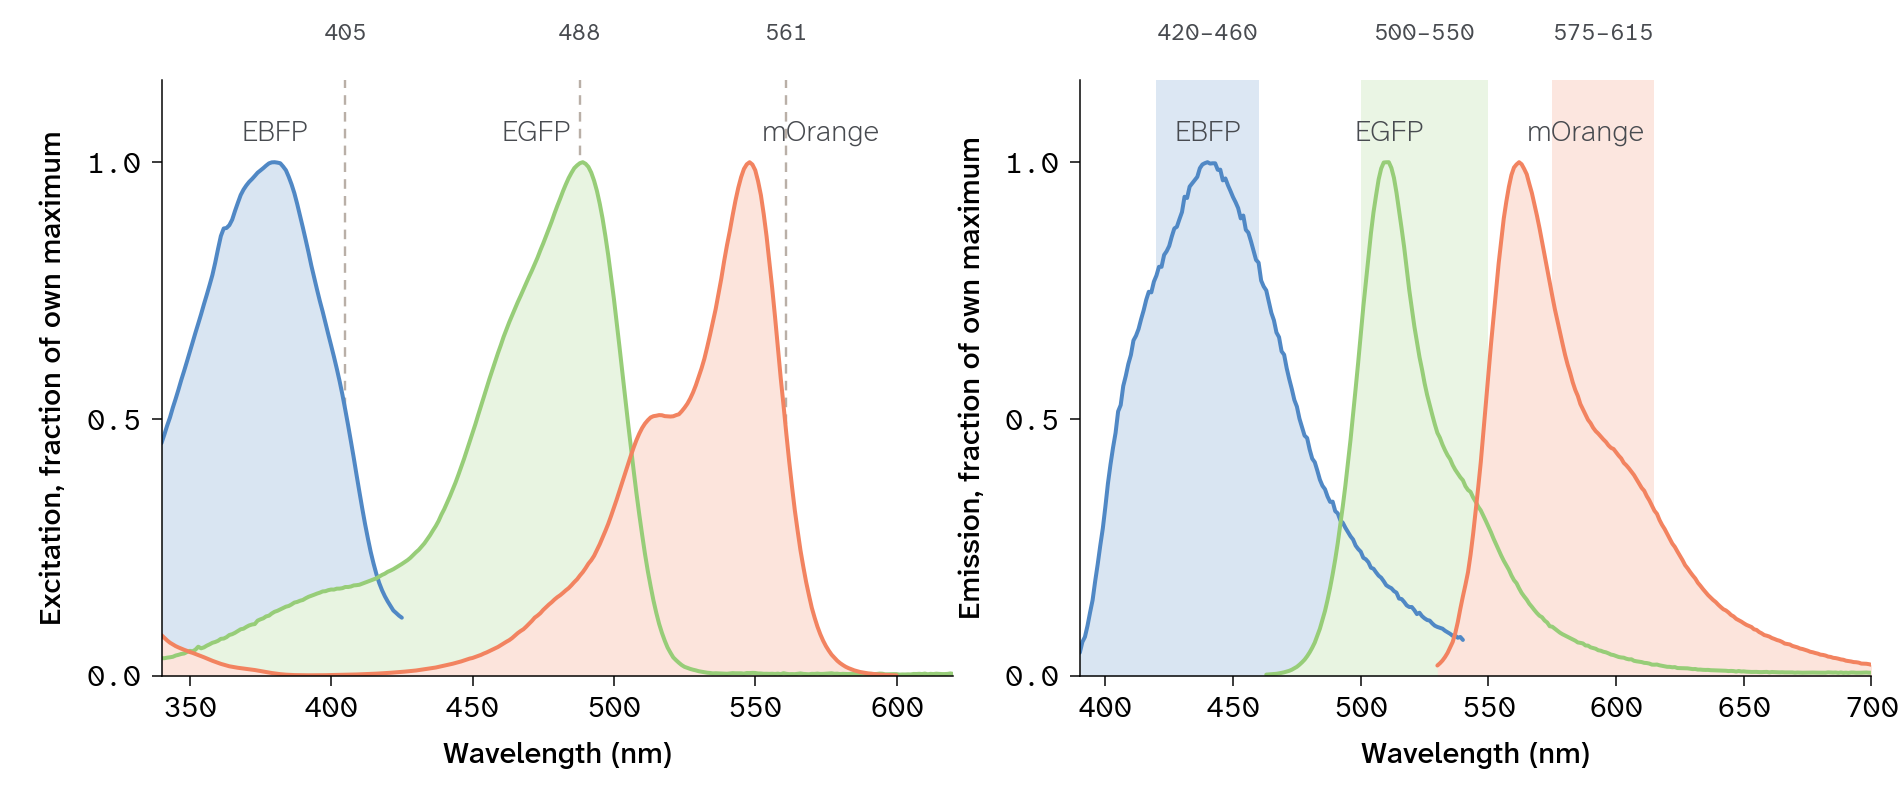

recorded range of each curve (everything outside it is padding, not an observed zero):
  EBFP     excitation 325-425 nm, emission 380-540 nm
  EGFP     excitation 300-700 nm, emission 463-700 nm
  mOrange  excitation 300-600 nm, emission 530-700 nm

per protein and channel: excitation at the line, share of emission inside the window,
and their product -- the signal that channel collects, relative to that protein's own peak
protein channel  ex_at_line  ex_recorded  em_in_band  band_recorded  signal
   EBFP    Blue       0.518         True      0.4979            100  0.2580
   EBFP   Green       0.000        False      0.0766             80  0.0000
   EBFP  Orange       0.000        False      0.0000              0  0.0000
   EGFP    Blue       0.173         True      0.0000              0  0.0000
   EGFP   Green       0.998         True      0.7173            100  0.7161
   EGFP  Orange       0.004         True      0.0473            100  0.0002
mOrange    Blue       0.002         True 

In [12]:
# The three proteins' measured curves, and what a conventional three-channel filter set would
# collect from each. Read from dataset_pipeline/data/spectra/curated/ -- the same 382-protein
# curated set the full-curve campaign trains on -- rather than copied, so the repo keeps one source
# for these spectra.
import csv        # noqa: E402

SPECTRA = CAMP.parent / "dataset_pipeline" / "data" / "spectra" / "curated"
_srows = sorted(csv.DictReader(open(SPECTRA / "spectra_assignments.csv")),
                key=lambda r: int(r["index"]))
SPEC_NAMES = [r["name"] for r in _srows]
EXC, EMI = np.load(SPECTRA / "excitation.npy"), np.load(SPECTRA / "emission.npy")
WEX = np.load(SPECTRA / "excitation_wavelengths.npy")
WEM = np.load(SPECTRA / "emission_wavelengths.npy")

# Standard lines and the detection window each one is paired with, one channel per protein here.
CHANNEL = {"Blue": dict(line=405, band=(420, 460), owner="EBFP"),
           "Green": dict(line=488, band=(500, 550), owner="EGFP"),
           "Orange": dict(line=561, band=(575, 615), owner="mOrange")}
PROTEINS = ["EBFP", "EGFP", "mOrange"]
PROT_COLOR = {"EGFP": SCAFFOLD_COLOR, **TARGET_COLOR}


def curve(protein, kind):
    """One protein's measured curve, plus a mask for the range FPbase actually recorded.

    The stored arrays are zero-padded onto a common grid, so a plain read of EBFP at 488 nm returns
    0 for a wavelength nobody measured. Every number and every line below distinguishes the two:
    a padded zero is reported as such rather than counted as an observed zero.
    """
    y = (EXC if kind == "ex" else EMI)[SPEC_NAMES.index(protein)]
    w = WEX if kind == "ex" else WEM
    nz = np.flatnonzero(y > 0)
    return w, y, (w >= w[nz[0]]) & (w <= w[nz[-1]])


det = []
for p in PROTEINS:
    wx, ex, mx = curve(p, "ex")
    wm, em, mm = curve(p, "em")
    for ch, c in CHANNEL.items():
        lo, hi = c["band"]
        i = int(np.argmin(np.abs(wx - c["line"])))
        band = (wm >= lo) & (wm <= hi)
        e, f = float(ex[i]), float(em[band].sum() / em.sum())
        det.append(dict(protein=p, channel=ch, ex_at_line=round(e, 3),
                        ex_recorded=bool(mx[i]),
                        em_in_band=round(f, 4),
                        band_recorded=round(100 * (band & mm).sum() / band.sum()),
                        signal=round(e * f, 4)))
DET = pd.DataFrame(det)
SIG = DET.pivot(index="protein", columns="channel", values="signal").loc[PROTEINS, list(CHANNEL)]
# Each column against the protein that channel exists for: crosstalk as a share of the signal the
# channel is meant to collect. Curves are peak-normalised per half, so this compares SHAPE only --
# extinction coefficient, quantum yield and expression are not in the curated spectra and not here.
XTALK = 100 * SIG / [SIG.loc[CHANNEL[c]["owner"], c] for c in SIG.columns]


def fig_channels(stem="bench_target_channels"):
    """The three proteins' spectra against the three channels they would be imaged in."""
    fig, axes = plt.subplots(1, 2, figsize=(0.95 * FULL_WIDE * PX, 400 * PX))
    fig.subplots_adjust(left=0.085, right=0.985, top=0.90, bottom=0.155, wspace=0.16)
    # Where each protein's name goes: at its own peak, nudged off it. Hand-picked rather than
    # computed -- the three peaks are far enough apart that only mOrange's needs pushing aside.
    AT = {"ex": {"EBFP": (0, "center"), "EGFP": (-6, "right"), "mOrange": (6, "left")},
          "em": {"EBFP": (0, "center"), "EGFP": (0, "center"), "mOrange": (4, "left")}}
    for ax, (kind, label, lo, hi) in zip(axes, [("ex", "Excitation", 340, 620),
                                                ("em", "Emission", 390, 700)]):
        apc.mpl.style_plot(ax, monospaced_axes="both")
        strip_spines(ax)
        for ch, c in CHANNEL.items():
            if kind == "ex":
                ax.axvline(c["line"], color=NEUTRAL, lw=1.2, ls=(0, (4, 3)), zorder=0)
                x, txt = c["line"], f"{c['line']}"
            else:
                b0, b1 = c["band"]
                # The window is tinted in the colour of the protein it is there to collect.
                ax.axvspan(b0, b1, color=tint(PROT_COLOR[c["owner"]], 0.20), lw=0, zorder=0)
                x, txt = 0.5 * (b0 + b1), f"{b0}–{b1}"
            ax.annotate(txt, xy=(x, 1.06), xycoords=("data", "axes fraction"), ha="center",
                        va="bottom", **{**NUMBER_NOTE, "fontsize": 11.5})
        for p in PROTEINS:
            w, y, rec = curve(p, kind)
            m = rec & (w >= lo) & (w <= hi)
            ax.fill_between(w[m], y[m], color=tint(PROT_COLOR[p], 0.22), lw=0, zorder=1)
            ax.plot(w[m], y[m], color=PROT_COLOR[p], lw=2, zorder=2)
            k = int(np.argmax(np.where(m, y, -1)))
            dx, ha = AT[kind][p]
            ax.annotate(p, xy=(w[k], y[k]), xytext=(dx, 8), textcoords="offset points", ha=ha,
                        va="bottom", zorder=4, **ANNOTATION)
        ax.set_xlim(lo, hi)
        ax.set_ylim(0, 1.16)
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel(f"{label}, fraction of own maximum")
    fig.savefig(f"{FIGDIR}/{stem}.svg")
    fig.savefig(f"{FIGDIR}/{stem}.png", dpi=200)
    plt.show()


fig_channels()
print("recorded range of each curve (everything outside it is padding, not an observed zero):")
for p in PROTEINS:
    (wx, _, mx), (wm, _, mm) = curve(p, "ex"), curve(p, "em")
    print(f"  {p:8} excitation {wx[mx][0]:.0f}-{wx[mx][-1]:.0f} nm,"
          f" emission {wm[mm][0]:.0f}-{wm[mm][-1]:.0f} nm")
print("\nper protein and channel: excitation at the line, share of emission inside the window,\n"
      "and their product -- the signal that channel collects, relative to that protein's own peak")
print(DET.to_string(index=False))
print("\ncollected signal (ex at the line x emission in the band)")
print(SIG.to_string())
print("\ncrosstalk: % of the signal the channel's intended protein gives it")
print(XTALK.round(1).to_string())
print("\n  ex_recorded = False means the line falls outside the wavelengths FPbase measured for that"
      "\n  protein, so the 0 is padding; band_recorded is the % of the window that is measured."
      "\n  EBFP's excitation is recorded only to 425 nm, where it is still at 0.113 of its peak and"
      "\n  falling steeply -- its 0 at 488 nm is a physical inference, not an observation."
      "\n  Shape only: the curated spectra carry no extinction coefficient or quantum yield, so this"
      "\n  says nothing about how much light each protein gives per molecule.")

**Figure 6. The two targets are dark in the green channel the brightness classifier was trained to
read.** Measured excitation (**left**) and emission (**right**) spectra of the EGFP scaffold (green)
and the two campaign targets, EBFP (blue) and mOrange (orange), from the 382-protein curated
spectrum set, each curve normalised to its own maximum and drawn only across the wavelengths FPbase
records for it. Dashed rules on the excitation panel are three standard excitation lines (405, 488
and 561 nm); shaded bands on the emission panel are the matching detection windows (420 – 460,
500 – 550 and 575 – 615 nm), each tinted in the colour of the protein its channel exists to collect.
Under 488 nm excitation with a 500 – 550 nm window — the green channel, and the configuration the
GFP DMS assays behind the brightness classifier score their libraries in — EGFP collects 0.716 of
its own peak signal, mOrange 0.016 (2.2 % of EGFP's) and EBFP 0.000 (0.0 %). The three channels are
mutually clean when each is driven by its own line: the largest off-diagonal entry of the 3 × 3
crosstalk matrix is that same 2.2 %, and EGFP contributes 0.1 % to the orange channel. The one
overlap a filter cannot remove is in absorption — mOrange is excited to 0.196 of its own maximum at
488 nm — which matters for simultaneous two-colour imaging but not for the assay label. EBFP's
excitation was recorded only to 425 nm (0.113 of peak there) and its emission only to 540 nm, so its
two zero entries are inferences from a steeply falling measured edge rather than observations.
Curves are peak-normalised per half and therefore carry shape alone: extinction coefficient and
quantum yield are not in the curated set, and every number here is relative to each protein's own
maximum rather than to the others.

Read together with Section 8, this is one statement made twice. The brightness classifier's label
comes from how much light a variant puts into the green window; both targets put essentially none
there, by construction, because moving out of that window is what the campaign asked for. A design
that succeeds at the stated objective is scored dim by the term meant to keep it foldable, and the
two demands can only be separated by a brightness judge that does not read a single colour — a
folding or maturation model, an orthologue DMS in the target's own band, or a measurement.